Starting sEMG Pipeline with MHA Model and Recovery Evaluation...

=== Phase 1 & 2: Loading All Data & Feature Extraction for Training ===
's4_full.mat' already exists or CREATE_DUMMY is False. Skipping creation.
Processing all data from 5 trials and 7 tasks...
Successfully loaded 35 valid data segment(s).
Detected 8 EMG channels and 14 Angle channels.
Creating windows (size=200, step=50) and extracting features...
Windowing and feature extraction completed in 1.93 seconds.
Total windows created: 2695
Feature vector size per window: 72
Target vector size per window: 14

Data Split for Training: Train+Validation 2287, Test 404
Fitting feature scaler...
Fitting target scaler...
Scaled training and test sets.

=== Phase 3: Model Training (MHA/Transformer) ===
Building MHA model with input shape: (None, 5, 72)
PositionalEmbedding initialized: sequence_length=5, output_dim=128, effective_input_dim=5
Creating output heads for fingers:
 - Thumb: 2 angles (Indices: [0, 1])
 - Index: 3 angles (I

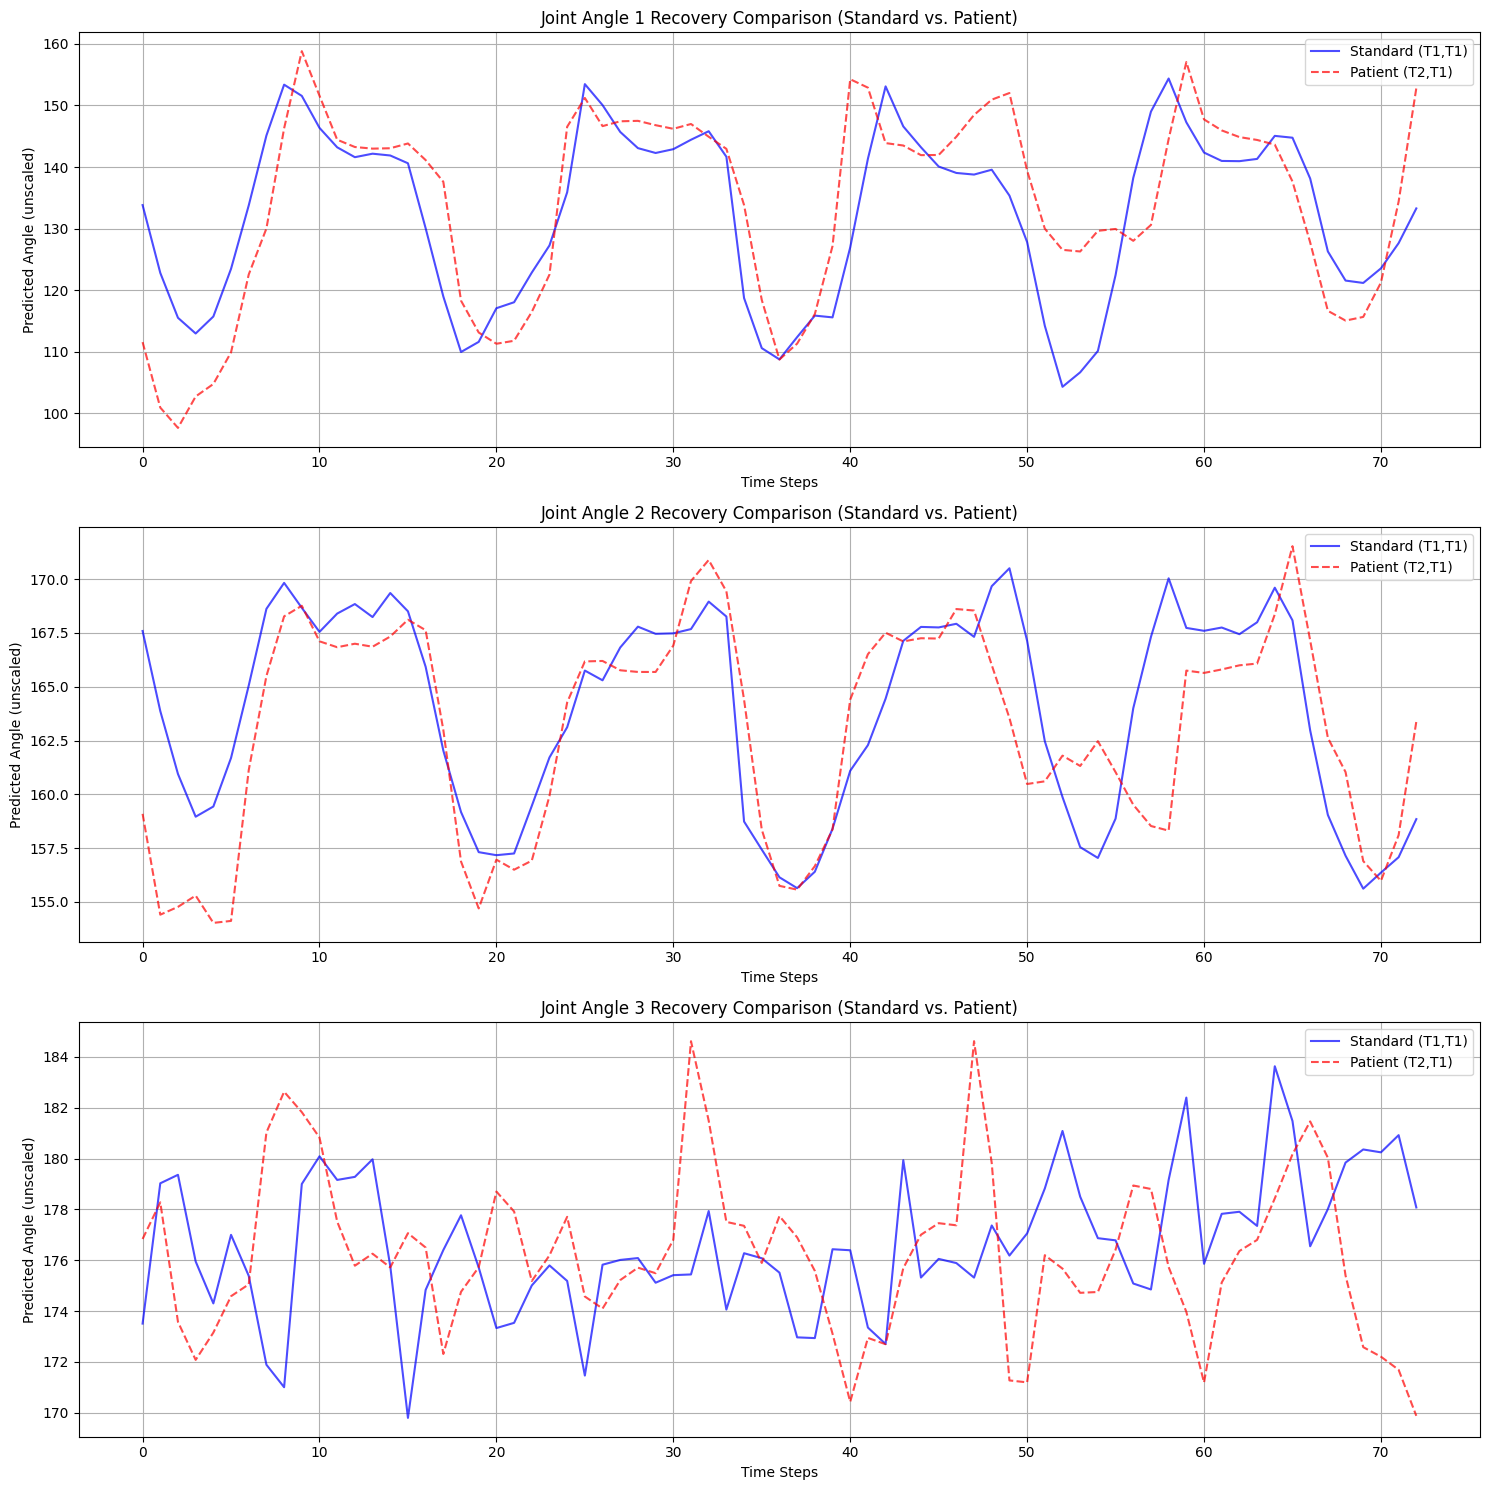

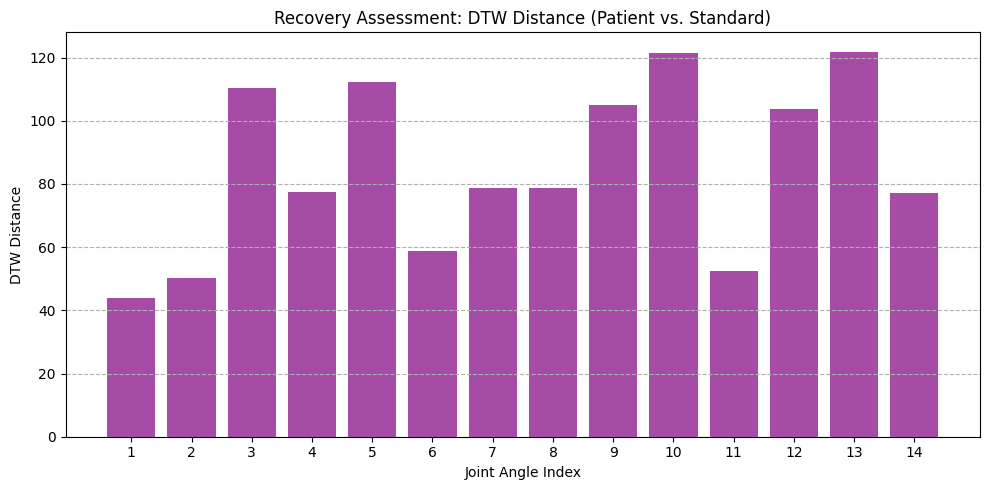

In [ ]:
# -*- coding: utf-8 -*-
"""
Pipeline for sEMG-based Joint Angle Estimation and Recovery Evaluation using Multi-Head Attention and DTW.

Phases:
1. Data Loading & Preprocessing (.mat file) - Modified for Standard/Patient selection
2. Feature Extraction (Windowing, RMS, Wavelet Packet Energy)
3. Model Building & Training (Multi-Head Attention / Transformer Encoder) - Modified
4. Recovery Evaluation (Predict angles for Standard & Patient, Compare using DTW)
5. Visualization (Time Series Overlay, DTW Alignment, Metrics Bar Chart) - DTW Plot Fixed
6. Conceptual Signal Adjustment (Placeholder)
"""

import os
import time
import numpy as np
import scipy.io
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import pywt  # For Wavelets
import tensorflow as tf
# Import necessary layers for MHA/Transformer
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input, TimeDistributed,
    MultiHeadAttention, LayerNormalization, Add, Embedding, Flatten, Concatenate, GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping
from scipy.optimize import minimize # For conceptual Phase 6
import matplotlib.pyplot as plt
from dtw import dtw # Import Dynamic Time Warping

# --- Configuration ---
MAT_FILE_PATH = 's4_full.mat' # Make sure this file exists or set CREATE_DUMMY = True
CREATE_DUMMY = False # Set to True if you want to generate dummy data

# --- Recovery Evaluation Configuration ---
STANDARD_TRIAL_IDX = 0
STANDARD_TASK_IDX = 0
PATIENT_TRIAL_IDX = 1
PATIENT_TASK_IDX = 0

# --- General Configuration ---
WINDOW_SIZE = 200
STEP_SIZE = 50
SEQUENCE_LENGTH = 5

# Feature Extraction Parameters
WAVELET_NAME = 'db4'
WAVELET_LEVELS = 3

# --- Model parameters (Updated for MHA/Transformer) ---
NUM_HEADS = 8
# Ensure D_MODEL is divisible by NUM_HEADS
D_MODEL = 128 # Embedding dimension (128 % 8 == 0)
FF_DIM = 128
NUM_TRANSFORMER_BLOCKS = 1
DROPOUT_RATE = 0.2

# Training parameters
LEARNING_RATE = 0.001
EPOCHS = 50
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.2
TEST_SPLIT_SIZE = 0.15

# Define joint angle mapping to fingers (0-based indices)
FINGER_JOINT_MAP = {
    'thumb': [0, 1], 'index': [2, 3, 4], 'middle': [5, 6, 7],
    'ring': [8, 9, 10], 'little': [11, 12, 13]
}
FINGER_ORDER = ['thumb', 'index', 'middle', 'ring', 'little']

# --- Utility: Dummy Data Creation ---
# (Function remains the same)
def create_dummy_mat_file(filename="s4_full.mat", trials=3, tasks=4, samples=2000, emg_channels=8, angle_channels=14):
    if not CREATE_DUMMY or os.path.exists(filename):
        if os.path.exists(filename): print(f"'{filename}' already exists or CREATE_DUMMY is False. Skipping creation.")
        else: print("CREATE_DUMMY is False. Please provide the actual data file.")
        return
    print(f"Creating dummy data file: '{filename}'...")
    dsfilt_emg_cell = np.empty((trials, tasks), dtype=object)
    joint_angles_cell = np.empty((trials, tasks), dtype=object)
    finger_kinematics_cell = np.empty((trials, tasks), dtype=object)
    for i in range(trials):
        for j in range(tasks):
            time_vec = np.linspace(0, samples / 100, samples); emg_signal = np.random.randn(samples, emg_channels) * 0.1
            task_mod = (np.sin(time_vec * np.pi * (j + 1) / 5 + i*0.5) + 1.1)
            for k in range(emg_channels): emg_signal[:, k] += np.sin(time_vec * (k + 1) * np.pi * 2 + np.random.rand() * np.pi + i*0.2) * (np.random.rand() * 0.5 + 0.5) * task_mod
            angle_signal = np.zeros((samples, angle_channels)); base_angle_pattern = np.convolve(task_mod, np.ones(50)/50, mode='same')
            for k in range(angle_channels):
                noise = np.random.randn(samples) * 0.05; variation = (np.sin(time_vec * (k+1) * 0.3 * np.pi + np.random.rand() * np.pi + i*0.3) + 1.1) / 2.2
                angle_signal[:, k] = np.clip(base_angle_pattern * variation + noise, 0, 1)
            dsfilt_emg_cell[i, j] = emg_signal.astype(np.float32); joint_angles_cell[i, j] = angle_signal.astype(np.float32)
            finger_kinematics_cell[i, j] = np.random.rand(samples, 69).astype(np.float32)
    mat_data = {'dsfilt_emg': dsfilt_emg_cell, 'joint_angles': joint_angles_cell, 'finger_kinematics': finger_kinematics_cell}
    scipy.io.savemat(filename, mat_data); print(f"Dummy data file '{filename}' created successfully.")

# --- Phase 1: Data Loading and Preprocessing ---
# (Function remains the same)
def load_and_preprocess_data(filepath, specific_trial=None, specific_task=None):
    try: create_dummy_mat_file(filepath); mat_contents = scipy.io.loadmat(filepath)
    except FileNotFoundError: print(f"Error: File not found at {filepath}"); return None, None, 0, 0
    except Exception as e: print(f"Error loading MAT file: {e}"); return None, None, 0, 0
    required_vars = ['dsfilt_emg', 'joint_angles']
    if not all(var in mat_contents for var in required_vars): print(f"Error: MAT file must contain variables: {required_vars}"); return None, None, 0, 0
    emg_cells = mat_contents['dsfilt_emg']; angle_cells = mat_contents['joint_angles']
    # --- Add check for variable existence before accessing shape ---
    if emg_cells is None or angle_cells is None:
        print("Error: Required variables ('dsfilt_emg', 'joint_angles') not found or are empty in the MAT file.")
        return None, None, 0, 0
    # --- End Add check ---
    if not hasattr(emg_cells, 'shape') or not hasattr(angle_cells, 'shape') or emg_cells.shape != angle_cells.shape:
        print(f"Error: Cell array dimensions mismatch or invalid type. EMG type: {type(emg_cells)}, Angle type: {type(angle_cells)}")
        return None, None, 0, 0

    num_trials, num_tasks = emg_cells.shape; all_emg_segments = []; all_angle_segments = []; emg_channels = 0; angle_channels = 0
    if specific_trial is not None and specific_task is not None:
        if 0 <= specific_trial < num_trials and 0 <= specific_task < num_tasks: trial_indices, task_indices = [specific_trial], [specific_task]; print(f"Loading specific segment: Trial {specific_trial+1}, Task {specific_task+1}")
        else: print(f"Error: Specific trial/task index ({specific_trial}, {specific_task}) out of bounds ({num_trials}, {num_tasks})."); return None, None, 0, 0
    else: trial_indices, task_indices = range(num_trials), range(num_tasks); print(f"Processing all data from {num_trials} trials and {num_tasks} tasks...")

    for i in trial_indices:
        for j in task_indices:
            # --- Add check for valid cell content ---
            if i >= emg_cells.shape[0] or j >= emg_cells.shape[1]:
                print(f"Warning: Index ({i},{j}) out of bounds for cell array shape {emg_cells.shape}. Skipping.")
                continue
            emg_segment, angle_segment = emg_cells[i, j], angle_cells[i, j]
            # --- End Add check ---

            if not isinstance(emg_segment, np.ndarray) or not isinstance(angle_segment, np.ndarray): print(f"Warning: Cell ({i},{j}) does not contain numpy array. Skipping."); continue
            if emg_segment.ndim != 2 or angle_segment.ndim != 2: print(f"Warning: Cell ({i},{j}) data not 2D. Skipping."); continue
            if emg_segment.shape[0] != angle_segment.shape[0]: print(f"Warning: Cell ({i},{j}) sample count mismatch. Skipping."); continue
            if emg_segment.shape[0] < WINDOW_SIZE: print(f"Warning: Cell ({i},{j}) segment too short ({emg_segment.shape[0]} < {WINDOW_SIZE}). Skipping."); continue

            all_emg_segments.append(emg_segment.astype(np.float32)); all_angle_segments.append(angle_segment.astype(np.float32))
            if emg_channels == 0: emg_channels = emg_segment.shape[1]
            if angle_channels == 0: angle_channels = angle_segment.shape[1]
            if emg_segment.shape[1] != emg_channels or angle_segment.shape[1] != angle_channels: print(f"Error: Inconsistent channel counts in cell ({i},{j})."); return None, None, 0, 0

    if not all_emg_segments: print("Error: No valid data segments found after processing cells."); return None, None, 0, 0
    print(f"Successfully loaded {len(all_emg_segments)} valid data segment(s).")
    if specific_trial is None: print(f"Detected {emg_channels} EMG channels and {angle_channels} Angle channels.")
    if specific_trial is not None: return all_emg_segments[0], all_angle_segments[0], emg_channels, angle_channels
    else: return all_emg_segments, all_angle_segments, emg_channels, angle_channels

# --- Phase 2: Feature Extraction ---
# (Functions remain the same)
def calculate_rms(segment): return np.sqrt(np.mean(segment**2, axis=0))
def calculate_wavelet_packet_energy(segment, wavelet, maxlevel):
    try: wp = pywt.WaveletPacket(data=segment, wavelet=wavelet, mode='symmetric', maxlevel=maxlevel); nodes = wp.get_level(maxlevel, order='natural')
    except Exception as e: num_features = 2**maxlevel; return np.zeros(num_features)
    if isinstance(nodes, pywt.WaveletPacket): nodes = [nodes]
    if not nodes or not all(isinstance(n, pywt.WaveletPacket) for n in nodes): num_features = 2**maxlevel; return np.zeros(num_features)
    coeffs = [n.data for n in nodes if n.data is not None and len(n.data) > 0]
    if not coeffs: num_features = 2**maxlevel; return np.zeros(num_features)
    energy = []; [energy.append(np.sum(np.asarray(c).ravel()**2)) if np.asarray(c).ravel().size > 0 else energy.append(0.0) for c in coeffs]
    if not energy: num_features = 2**maxlevel; return np.zeros(num_features)
    energy = np.array(energy, dtype=np.float32); total_energy = np.sum(energy)
    if total_energy > 1e-9: energy = energy / total_energy
    else: energy = np.zeros_like(energy)
    num_expected_features = 2**maxlevel
    if len(energy) < num_expected_features: padded_energy = np.zeros(num_expected_features, dtype=np.float32); padded_energy[:len(energy)] = energy; energy = padded_energy
    elif len(energy) > num_expected_features: energy = energy[:num_expected_features]
    return energy
def extract_features_from_window(window_emg):
    num_channels = window_emg.shape[1]; all_features = []; rms_features = calculate_rms(window_emg); all_features.append(rms_features)
    for ch in range(num_channels):
        channel_data = window_emg[:, ch].squeeze();
        if channel_data.ndim == 0: channel_data = np.array([channel_data])
        if channel_data.ndim == 1 and len(channel_data) > 0: wp_energy = calculate_wavelet_packet_energy(channel_data, WAVELET_NAME, WAVELET_LEVELS); all_features.append(wp_energy)
        else: num_wavelet_features = 2**WAVELET_LEVELS; all_features.append(np.zeros(num_wavelet_features))
    all_features = [np.asarray(f, dtype=np.float32) for f in all_features]; return np.concatenate(all_features)
def create_windows_and_features(emg_segments, angle_segments, window_size, step_size):
    if not isinstance(emg_segments, list): emg_segments, angle_segments = [emg_segments], [angle_segments]
    all_window_features, all_window_targets = [], []
    print(f"Creating windows (size={window_size}, step={step_size}) and extracting features...")
    start_time = time.time()
    for seg_idx, (emg_seg, angle_seg) in enumerate(zip(emg_segments, angle_segments)):
        n_samples = emg_seg.shape[0]
        for start in range(0, n_samples - window_size + 1, step_size):
            end = start + window_size; window_emg = emg_seg[start:end, :]; window_target_angle = angle_seg[end - 1, :]
            features = extract_features_from_window(window_emg); all_window_features.append(features); all_window_targets.append(window_target_angle)
    elapsed_time = time.time() - start_time; print(f"Windowing and feature extraction completed in {elapsed_time:.2f} seconds.")
    if not all_window_features: print("Error: No features were extracted."); return None, None
    features_array = np.array(all_window_features, dtype=np.float32); targets_array = np.array(all_window_targets, dtype=np.float32)
    print(f"Total windows created: {features_array.shape[0]}")
    if features_array.shape[0] > 0: print(f"Feature vector size per window: {features_array.shape[1]}"); print(f"Target vector size per window: {targets_array.shape[1]}")
    else: print("Warning: features_array is empty after windowing.")
    return features_array, targets_array

# Function: create_sequences (Remains the same)
def create_sequences(features, targets, sequence_length):
    X_seq, y_seq = [], []; n_samples = features.shape[0]
    if n_samples < sequence_length: print(f"Warning: Not enough samples ({n_samples}) for sequence length {sequence_length}. Returning None."); return None, None
    for i in range(n_samples - sequence_length + 1): X_seq.append(features[i : i + sequence_length]); y_seq.append(targets[i + sequence_length - 1])
    if not X_seq: print("Warning: No sequences created."); return None, None
    X_seq = np.array(X_seq, dtype=np.float32); y_seq = np.array(y_seq, dtype=np.float32); return X_seq, y_seq

# --- Phase 3: Model Building & Training (Using MHA/Transformer) ---

# Helper Layer for Positional Embedding
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, sequence_length, output_dim, **kwargs):
        super().__init__(**kwargs)
        self.eff_sequence_length = max(1, sequence_length)
        self.position_embeddings = Embedding(input_dim=self.eff_sequence_length, output_dim=output_dim)
        self.sequence_length = sequence_length; self.output_dim = output_dim
        print(f"PositionalEmbedding initialized: sequence_length={sequence_length}, output_dim={output_dim}, effective_input_dim={self.eff_sequence_length}")
    def call(self, inputs):
        length = tf.shape(inputs)[1]; positions = tf.range(start=0, limit=length, delta=1)
        positions = tf.clip_by_value(positions, 0, self.eff_sequence_length - 1)
        embedded_positions = self.position_embeddings(positions); return inputs + embedded_positions
    def compute_mask(self, inputs, mask=None): return None

# Transformer Encoder Block Layer
class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim; self.dense_dim = dense_dim; self.num_heads = num_heads
        if embed_dim % num_heads != 0: raise ValueError(f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})")
        self.key_dim = embed_dim // num_heads
        self.attention = MultiHeadAttention(num_heads=num_heads, key_dim=self.key_dim, dropout=dropout_rate)
        self.dense_proj = tf.keras.Sequential([Dense(dense_dim, activation="relu"), Dense(embed_dim),])
        self.layernorm_1 = LayerNormalization(); self.layernorm_2 = LayerNormalization()
        self.dropout_1 = Dropout(dropout_rate); self.dropout_2 = Dropout(dropout_rate)
        self.supports_masking = True
    def call(self, inputs, mask=None):
        attention_output = self.attention(query=inputs, value=inputs, key=inputs, attention_mask=mask)
        attention_output = self.dropout_1(attention_output)
        proj_input = self.layernorm_1(inputs + attention_output)
        dense_output = self.dense_proj(proj_input)
        dense_output = self.dropout_2(dense_output)
        proj_output = self.layernorm_2(proj_input + dense_output); return proj_output

def build_mha_model(input_shape, output_units, num_transformer_blocks=NUM_TRANSFORMER_BLOCKS,
                    d_model=D_MODEL, num_heads=NUM_HEADS, ff_dim=FF_DIM, dropout_rate=DROPOUT_RATE):
    """Builds the Transformer-based model with finger-specific output heads."""
    sequence_length, num_features = input_shape
    print(f"Building MHA model with input shape: (None, {sequence_length}, {num_features})")
    inputs = Input(shape=input_shape, name="Input_Sequence")
    x = Dense(d_model, name="Input_Projection")(inputs)
    x = PositionalEmbedding(sequence_length=sequence_length, output_dim=d_model, name="Positional_Embedding")(x)
    for i in range(num_transformer_blocks): x = TransformerEncoder(embed_dim=d_model, dense_dim=ff_dim, num_heads=num_heads, dropout_rate=dropout_rate, name=f"Transformer_Block_{i+1}")(x)
    x = x[:, -1, :] # Use output of the last time step
    output_heads = []; print("Creating output heads for fingers:")
    for finger in FINGER_ORDER:
        joint_indices = FINGER_JOINT_MAP[finger]; num_finger_joints = len(joint_indices)
        print(f" - {finger.capitalize()}: {num_finger_joints} angles (Indices: {joint_indices})")
        head_output = Dense(num_finger_joints, name=f"Output_{finger}")(x); output_heads.append(head_output)
    concatenated_output = Concatenate(name="Concatenated_Output")(output_heads)
    model = Model(inputs=inputs, outputs=concatenated_output, name="sEMG_MHA_Estimator")
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    model.compile(loss='mean_squared_error', optimizer=optimizer, metrics=['mean_absolute_error'], run_eagerly=True) # Keep eager execution for debugging if needed
    print("\nMulti-Head Attention Model Built Successfully:"); model.summary(); return model


# --- Phase 4: Recovery Evaluation using DTW ---
# (Functions remain the same)
def predict_angles_for_segment(model, emg_segment, feature_scaler, target_scaler):
    print("Predicting angles for segment...")
    if not hasattr(target_scaler, 'n_features_in_'):
        if model.output_shape[-1] is None: print("Error: Cannot determine target dimension."); return None
        target_dim = model.output_shape[-1]; print(f"Warning: Inferring target dimension from model output: {target_dim}")
    else: target_dim = target_scaler.n_features_in_
    dummy_angles = np.zeros((emg_segment.shape[0], target_dim))
    features, _ = create_windows_and_features(emg_segment, dummy_angles, WINDOW_SIZE, STEP_SIZE)
    if features is None or features.shape[0] == 0: return None
    if not hasattr(feature_scaler, 'mean_'): print("Error: feature_scaler is not fitted."); return None
    features_scaled = feature_scaler.transform(features)
    X_sequences, _ = create_sequences(features_scaled, features_scaled, SEQUENCE_LENGTH)
    if X_sequences is None: return None
    print(f"Shape for prediction: {X_sequences.shape}")
    y_pred_scaled = model.predict(X_sequences)
    y_pred_unscaled = target_scaler.inverse_transform(y_pred_scaled)
    print(f"Prediction complete. Output shape: {y_pred_unscaled.shape}"); return y_pred_unscaled
def calculate_dtw_distance(sequence1, sequence2):
    seq1_norm = (sequence1 - np.mean(sequence1)) / (np.std(sequence1) + 1e-9)
    seq2_norm = (sequence2 - np.mean(sequence2)) / (np.std(sequence2) + 1e-9)
    try:
         if seq1_norm.ndim > 1 or seq2_norm.ndim > 1: raise ValueError("Input sequences for DTW distance should be 1D.")
         dtw_result = dtw(seq1_norm, seq2_norm, keep_internals=True, step_pattern='symmetricP2', dist_method=lambda x, y: np.linalg.norm(x - y, ord=1))
         distance = dtw_result.distance
    except Exception as e: print(f"Error during DTW calculation: {e}"); distance = np.inf; dtw_result = None
    return distance, dtw_result
def evaluate_recovery(standard_angles_pred, patient_angles_pred):
    if standard_angles_pred is None or patient_angles_pred is None: return None, None
    num_angles = standard_angles_pred.shape[1]
    if patient_angles_pred.shape[1] != num_angles: return None, None
    print("\n--- Recovery Evaluation (Comparing Patient to Standard using DTW) ---")
    dtw_distances = []; dtw_results = {}
    header = f"{'Joint':<7} {'DTW Distance':<15}"; print(header); print("-" * len(header))
    for i in range(num_angles):
        seq_standard = standard_angles_pred[:, i]; seq_patient = patient_angles_pred[:, i]
        if len(seq_standard) < 2 or len(seq_patient) < 2 or np.std(seq_standard) < 1e-9 or np.std(seq_patient) < 1e-9:
             print(f"{i+1:<7} {'Skipped (Invalid Seq)':<15}"); dtw_dist = np.nan; dtw_res = None
        else: dtw_dist, dtw_res = calculate_dtw_distance(seq_standard, seq_patient); print(f"{i+1:<7} {dtw_dist:<15.4f}")
        dtw_distances.append(dtw_dist)
        if dtw_res: dtw_results[i] = dtw_res
    avg_dtw_dist = np.nanmean(dtw_distances); print("-" * len(header)); print(f"{'Average':<7} {avg_dtw_dist:<15.4f}"); print("-" * len(header))
    print("(Lower DTW Distance indicates higher similarity to the standard)")
    recovery_metrics = {'DTW_Distance': dtw_distances}; return recovery_metrics, dtw_results

# --- Phase 5: Visualization (Enhanced for Recovery) ---
# --- plot_dtw_alignment function FIXED ---
def plot_dtw_alignment(dtw_result, joint_index, filename_prefix="dtw_alignment_joint_"):
    """Plots the DTW alignment path for a specific joint."""
    if dtw_result is None: print(f"Skipping DTW alignment plot for Joint {joint_index+1}: No DTW result."); return
    print(f"Plotting DTW alignment for Joint {joint_index+1}...")
    try:
        # Let dtw.plot create its own figure/axes
        # Call plot first to generate the figure
        dtw_result.plot(type="alignment", # Removed ax=ax argument
                        title=f'DTW Alignment Path - Joint {joint_index+1}',
                        xlabel="Standard Sequence Index",
                        ylabel="Patient Sequence Index")
        fig = plt.gcf() # Get the current figure created by dtw.plot
        filename = f"{filename_prefix}{joint_index+1}.png"
        fig.tight_layout() # Apply tight layout to the captured figure
        fig.savefig(filename) # Save the captured figure
        print(f"DTW alignment plot saved to '{filename}'")
        plt.close(fig) # Close the captured figure
    except AttributeError:
         print(f"Warning: Could not plot DTW for Joint {joint_index+1}. The 'plot' method might not be available or failed.")
         plt.close(plt.gcf()) # Attempt to close any dangling figure
    except Exception as e:
        print(f"Warning: Could not save/plot DTW alignment for Joint {joint_index+1}. {e}")
        plt.close(plt.gcf()) # Attempt to close any dangling figure

# (Other plotting functions remain the same)
def plot_recovery_timeseries(standard_angles, patient_angles, num_angles_to_plot=3, filename="recovery_timeseries_plot.png"):
    print(f"Plotting recovery time series comparison for the first {num_angles_to_plot} angles...")
    num_angles = standard_angles.shape[1]; angles_to_plot = min(num_angles_to_plot, num_angles)
    if angles_to_plot == 0: return
    plt.figure(figsize=(15, 5 * angles_to_plot))
    for i in range(angles_to_plot):
        plt.subplot(angles_to_plot, 1, i + 1)
        plt.plot(standard_angles[:, i], label=f'Standard (T{STANDARD_TRIAL_IDX+1},T{STANDARD_TASK_IDX+1})', color='blue', alpha=0.7)
        plt.plot(patient_angles[:, i], label=f'Patient (T{PATIENT_TRIAL_IDX+1},T{PATIENT_TASK_IDX+1})', color='red', linestyle='--', alpha=0.7)
        plt.title(f'Joint Angle {i+1} Recovery Comparison (Standard vs. Patient)'); plt.xlabel('Time Steps'); plt.ylabel('Predicted Angle (unscaled)'); plt.legend(); plt.grid(True)
    plt.tight_layout();
    try: plt.savefig(filename); print(f"Recovery time series plot saved to '{filename}'");
    except Exception as e: print(f"Warning: Could not save recovery time series plot. {e}")
def plot_recovery_metrics_bar(recovery_metrics, filename="recovery_metrics_bar_plot.png"):
    if not recovery_metrics or 'DTW_Distance' not in recovery_metrics: print("Warning: Recovery metrics missing. Skipping metrics bar plot."); return
    print("Plotting recovery metrics (DTW Distance) across joints...")
    dtw_distances = recovery_metrics['DTW_Distance']; num_angles = len(dtw_distances)
    if num_angles == 0: return
    joint_indices = np.arange(1, num_angles + 1); plt.figure(figsize=(max(10, num_angles * 0.6), 5))
    plt.bar(joint_indices, dtw_distances, color='purple', alpha=0.7); plt.xlabel('Joint Angle Index'); plt.ylabel('DTW Distance')
    plt.title('Recovery Assessment: DTW Distance (Patient vs. Standard)'); plt.xticks(joint_indices); plt.grid(True, axis='y', linestyle='--')
    plt.tight_layout();
    try: plt.savefig(filename); print(f"Recovery metrics bar plot saved to '{filename}'");
    except Exception as e: print(f"Warning: Could not save recovery metrics plot. {e}")

# --- Phase 6: Conceptual Signal Adjustment (Placeholder) ---
# (Function remains the same)
def conceptual_signal_adjustment(model, target_angles_scaled, initial_features_scaled, feature_scaler, max_iter=50):
    print("\n--- Conceptual Signal Adjustment ---")
    num_features = initial_features_scaled.shape[-1]
    dummy_sequence = np.zeros((1, SEQUENCE_LENGTH, num_features), dtype=np.float32)
    dummy_sequence[0, -1, :] = initial_features_scaled
    def objective(features_last_step_flat):
        current_features_last_step = features_last_step_flat.reshape(1, num_features)
        temp_sequence = dummy_sequence.copy(); temp_sequence[0, -1, :] = current_features_last_step
        predicted_angles_scaled = model.predict(temp_sequence, verbose=0)[0]
        error = np.sum((predicted_angles_scaled - target_angles_scaled)**2); return error
    initial_guess = initial_features_scaled.flatten()
    result = minimize(objective, initial_guess, method='L-BFGS-B', options={'maxiter': max_iter, 'disp': False})
    if result.success: print("\nOptimization Successful!"); optimized_features_scaled = result.x.reshape(1, num_features); optimized_features_unscaled = feature_scaler.inverse_transform(optimized_features_scaled); return optimized_features_unscaled
    else: print("\nOptimization Failed."); return None


# --- Main Execution ---
if __name__ == "__main__":
    print("Starting sEMG Pipeline with MHA Model and Recovery Evaluation...")

    # --- Load General Data for Model Training ---
    print("\n=== Phase 1 & 2: Loading All Data & Feature Extraction for Training ===")
    all_emg_segments, all_angle_segments, n_emg_channels, n_angle_channels = load_and_preprocess_data(MAT_FILE_PATH)
    if all_emg_segments is None: exit("Exiting: Failed to load general data.")

    features, targets = create_windows_and_features(all_emg_segments, all_angle_segments, WINDOW_SIZE, STEP_SIZE)
    if features is None or features.shape[0] == 0: exit("Exiting: Failed to extract features for training.")

    X_sequences, y_sequences = create_sequences(features, targets, SEQUENCE_LENGTH)
    if X_sequences is None: exit("Exiting: Failed to create sequences for training.")

    # --- Data Splitting & Scaling for Training ---
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_sequences, y_sequences, test_size=TEST_SPLIT_SIZE, random_state=42, shuffle=True)
    print(f"\nData Split for Training: Train+Validation {X_train_val.shape[0]}, Test {X_test.shape[0]}")

    n_features = X_train_val.shape[2]
    X_train_val_reshaped = X_train_val.reshape(-1, n_features)
    if X_train_val_reshaped.shape[0] == 0: exit("Error: No training data for scaling.")

    feature_scaler = StandardScaler(); print("Fitting feature scaler..."); feature_scaler.fit(X_train_val_reshaped)
    X_train_val_scaled_reshaped = feature_scaler.transform(X_train_val_reshaped)
    X_train_val_scaled = X_train_val_scaled_reshaped.reshape(X_train_val.shape)

    target_scaler = MinMaxScaler(); print("Fitting target scaler...")
    if y_train_val.shape[0] == 0: exit("Error: No training targets for scaling.")
    target_scaler.fit(y_train_val)
    y_train_val_scaled = target_scaler.transform(y_train_val)

    if X_test.shape[0] > 0:
        X_test_reshaped = X_test.reshape(-1, n_features); X_test_scaled_reshaped = feature_scaler.transform(X_test_reshaped)
        X_test_scaled = X_test_scaled_reshaped.reshape(X_test.shape); y_test_scaled = target_scaler.transform(y_test)
        print("Scaled training and test sets.")
    else: X_test_scaled, y_test_scaled = np.array([]), np.array([]); print("Scaled training set. No test set.")

    # --- Phase 3: Train the MHA Model ---
    print("\n=== Phase 3: Model Training (MHA/Transformer) ===")
    input_shape = (SEQUENCE_LENGTH, n_features)
    model = build_mha_model(input_shape, n_angle_channels)

    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

    if X_train_val_scaled.shape[0] == 0: print("Error: No training data."); history = None
    else:
        print("Checking for NaNs/Infs in training data...")
        if np.isnan(X_train_val_scaled).any() or np.isinf(X_train_val_scaled).any(): print("ERROR: NaNs or Infs found in X_train_val_scaled!"); exit()
        if np.isnan(y_train_val_scaled).any() or np.isinf(y_train_val_scaled).any(): print("ERROR: NaNs or Infs found in y_train_val_scaled!"); exit()
        print("No NaNs/Infs found in training data.")

        print(f"Starting model training with X shape: {X_train_val_scaled.shape}, y shape: {y_train_val_scaled.shape}")
        history = model.fit(X_train_val_scaled, y_train_val_scaled,
                            epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=VALIDATION_SPLIT,
                            callbacks=[early_stopping], shuffle=True, verbose=1)
        print("--- Model Training Complete ---")

    # --- Phase 4: Recovery Evaluation ---
    print(f"\n=== Phase 4: Recovery Evaluation (Patient T{PATIENT_TRIAL_IDX+1},T{PATIENT_TASK_IDX+1} vs Standard T{STANDARD_TRIAL_IDX+1},T{STANDARD_TASK_IDX+1}) ===")
    print("\nLoading Standard Data..."); std_emg, _, _, _ = load_and_preprocess_data(MAT_FILE_PATH, specific_trial=STANDARD_TRIAL_IDX, specific_task=STANDARD_TASK_IDX)
    if std_emg is None: exit("Exiting: Failed to load standard data.")
    print("\nLoading Patient Data..."); pat_emg, _, _, _ = load_and_preprocess_data(MAT_FILE_PATH, specific_trial=PATIENT_TRIAL_IDX, specific_task=PATIENT_TASK_IDX)
    if pat_emg is None: exit("Exiting: Failed to load patient data.")

    if model is None or history is None: exit("Exiting: Model not trained.")
    if not hasattr(feature_scaler, 'mean_') or not hasattr(target_scaler, 'data_min_'): exit("Exiting: Scalers are not fitted.")

    standard_angles_pred = predict_angles_for_segment(model, std_emg, feature_scaler, target_scaler)
    patient_angles_pred = predict_angles_for_segment(model, pat_emg, feature_scaler, target_scaler)
    recovery_metrics, dtw_results = evaluate_recovery(standard_angles_pred, patient_angles_pred)

    # --- Phase 5: Recovery Visualization ---
    print("\n=== Phase 5: Recovery Visualization ===")
    if standard_angles_pred is not None and patient_angles_pred is not None:
        plot_recovery_timeseries(standard_angles_pred, patient_angles_pred, num_angles_to_plot=min(3, n_angle_channels))
        if dtw_results:
            for joint_idx in range(min(3, n_angle_channels)):
                if joint_idx in dtw_results: plot_dtw_alignment(dtw_results[joint_idx], joint_idx)
        if recovery_metrics: plot_recovery_metrics_bar(recovery_metrics)
    else: print("Skipping recovery visualization.")

    # --- Phase 6 (Conceptual Demo) ---
    # ...

    print("\nPipeline Finished.")


In [8]:
# ==============================================================================
# Imports
# ==============================================================================
import os
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import math # Added for ceil function

# ==============================================================================
# Configuration
# ==============================================================================
# --- File Paths ---
# !!! Replace with the actual path to your MAT file !!!
MAT_FILE_PATH = 's4_full.mat'

# --- Data Selection ---
# Select the task to analyze (0-6, corresponding to tasks 1-7)
# Task 6 (index 5) is simultaneous flexion/extension
TARGET_TASK_INDEX = 5
# Trials to use for training (e.g., Trials 2-5 -> indices 1-4)
TRAIN_TRIAL_INDICES = [1, 2, 3, 4]
# Trial to use as the standard/reference (Trial 1 -> index 0)
REFERENCE_TRIAL_INDEX = 0

# --- Model & Training Parameters ---
SEQUENCE_LENGTH = 100  # Length of EMG sequences to feed into the model
NUM_HEADS = 8          # Number of attention heads in the MHA layer
FF_DIM = 128           # Hidden layer size in feed forward network inside transformer block
EMBED_DIM = 64         # Embedding dimension for EMG channels after initial projection
NUM_TRANSFORMER_BLOCKS = 2 # Number of transformer blocks to stack
DROPOUT_RATE = 0.1     # Dropout rate for regularization
NUM_EPOCHS = 50        # Number of training epochs (adjust as needed)
BATCH_SIZE = 32        # Batch size for training
LEARNING_RATE = 0.001
VALIDATION_SPLIT = 0.2 # Fraction of training data to use for validation

# --- Output ---
OUTPUT_DIR = 'output_visualizations'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Finger Angle Mapping ---
# Define which angle indices belong to which finger for the output layers
# Based on the user description:
FINGER_ANGLE_INDICES = {
    'Thumb': [0, 1],      # Thumb 1, Thumb 2
    'Index': [2, 3, 4],   # Index 1, Index 2, Index 3
    'Middle': [5, 6, 7],  # Middle 1, Middle 2, Middle 3
    'Ring': [8, 9, 10],   # Ring 1, Ring 2, Ring 3
    'Little': [11, 12, 13] # Little 1, Little 2, Little 3
}
FINGERS = list(FINGER_ANGLE_INDICES.keys()) # ['Thumb', 'Index', 'Middle', 'Ring', 'Little']
NUM_FINGERS = len(FINGERS)
NUM_TOTAL_ANGLES = sum(len(v) for v in FINGER_ANGLE_INDICES.values()) # Should be 14

# ==============================================================================
# Data Loading and Preprocessing
# ==============================================================================

def load_mat_data(filepath):
    """Loads data from the specified .mat file."""
    try:
        print(f"Loading data from: {filepath}")
        # Check if the file exists before attempting to load
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"No such file or directory: '{filepath}'")
        mat_data = scipy.io.loadmat(filepath)
        print("Data loaded successfully.")
        # Print variable names and types for verification
        print("Variables in .mat file:")
        for key, value in mat_data.items():
            if not key.startswith('__'): # Exclude MATLAB metadata
                # Check if it's a cell array and print dimensions if so
                if isinstance(value, np.ndarray) and value.dtype == object:
                     print(f"  - {key}: type=cell array, shape={value.shape}")
                     # Optionally print shape of the first cell element if needed
                     # if value.size > 0 and isinstance(value[0,0], np.ndarray):
                     #     print(f"     First cell element shape: {value[0,0].shape}")
                else:
                     print(f"  - {key}: type={type(value)}, shape={getattr(value, 'shape', 'N/A')}")
        return mat_data
    except FileNotFoundError as fnf_error:
        print(f"Error: {fnf_error}")
        print("Please ensure the MAT_FILE_PATH variable is set correctly.")
        return None
    except Exception as e:
        print(f"Error loading .mat file: {e}")
        return None

def extract_and_preprocess_data(mat_data, task_index, train_trial_indices, ref_trial_index, sequence_length):
    """Extracts, preprocesses, and sequences data for a specific task."""
    if mat_data is None:
        return None, None, None, None, None, None

    # --- Extract Data ---
    try:
        # Adjust keys if they are different in your .mat file
        emg_data_cells = mat_data['dsfilt_emg']       # Expected shape: (5, 7) cell array
        angle_data_cells = mat_data['joint_angles']   # Expected shape: (5, 7) cell array
        print(f"EMG data shape (cells): {emg_data_cells.shape}")
        print(f"Angle data shape (cells): {angle_data_cells.shape}")
    except KeyError as e:
        print(f"Error: Variable {e} not found in the .mat file.")
        print("Please ensure the variable names ('dsfilt_emg', 'joint_angles') match your file.")
        return None, None, None, None, None, None
    except Exception as e:
        print(f"Error accessing data variables: {e}")
        return None, None, None, None, None, None


    # --- Select Task and Trials ---
    try:
        train_emg = np.concatenate([emg_data_cells[i, task_index] for i in train_trial_indices], axis=0)
        train_angles = np.concatenate([angle_data_cells[i, task_index] for i in train_trial_indices], axis=0)
        ref_emg = emg_data_cells[ref_trial_index, task_index]
        ref_angles = angle_data_cells[ref_trial_index, task_index]
    except IndexError:
         print(f"Error: Task index ({task_index}) or Trial indices ({train_trial_indices}, {ref_trial_index}) might be out of bounds for the cell array dimensions.")
         return None, None, None, None, None, None
    except ValueError as ve:
         print(f"Error concatenating data, likely due to inconsistent shapes within cells for the selected task/trials: {ve}")
         return None, None, None, None, None, None


    print(f"Selected Task {task_index + 1}")
    print(f"  Training EMG shape: {train_emg.shape}")      # Should be (N_train_samples, 8)
    print(f"  Training Angles shape: {train_angles.shape}") # Should be (N_train_samples, 14)
    print(f"  Reference EMG shape: {ref_emg.shape}")       # Should be (N_ref_samples, 8)
    print(f"  Reference Angles shape: {ref_angles.shape}")  # Should be (N_ref_samples, 14)

    # --- Basic Data Validation ---
    if train_emg.shape[1] != 8:
        print(f"Warning: Training EMG data does not have 8 columns (channels), found {train_emg.shape[1]}.")
    if train_angles.shape[1] != NUM_TOTAL_ANGLES: # Use config variable
        print(f"Warning: Training Angle data does not have {NUM_TOTAL_ANGLES} columns (angles), found {train_angles.shape[1]}.")
    if ref_emg.shape[0] > 0 and ref_emg.shape[1] != 8: # Check only if ref_emg exists
        print(f"Warning: Reference EMG data does not have 8 columns (channels), found {ref_emg.shape[1]}.")
    if ref_angles.shape[0] > 0 and ref_angles.shape[1] != NUM_TOTAL_ANGLES: # Check only if ref_angles exists
        print(f"Warning: Reference Angle data does not have {NUM_TOTAL_ANGLES} columns (angles), found {ref_angles.shape[1]}.")
    if train_emg.shape[0] != train_angles.shape[0]:
         print(f"Error: Mismatch between number of samples in training EMG ({train_emg.shape[0]}) and angles ({train_angles.shape[0]}).")
         return None, None, None, None, None, None
    if ref_emg.shape[0] > 0 and ref_emg.shape[0] != ref_angles.shape[0]: # Check only if ref_emg exists
         print(f"Error: Mismatch between number of samples in reference EMG ({ref_emg.shape[0]}) and angles ({ref_angles.shape[0]}).")
         return None, None, None, None, None, None


    # --- Normalize Data ---
    # Use MinMaxScaler: scales data to range [0, 1] or StandardScaler
    # Fit scaler ONLY on training data to prevent data leakage
    emg_scaler = MinMaxScaler()
    angle_scaler = MinMaxScaler()

    # Handle potential case where training data might be empty or too small
    if train_emg.shape[0] == 0 or train_angles.shape[0] == 0:
        print("Error: No training data available after selection.")
        return None, None, None, None, None, None

    train_emg_scaled = emg_scaler.fit_transform(train_emg)
    train_angles_scaled = angle_scaler.fit_transform(train_angles)

    # Scale reference data using the *same* scaler fitted on training data
    if ref_emg.shape[0] > 0 : # Only scale if there's reference data
        ref_emg_scaled = emg_scaler.transform(ref_emg)
        ref_angles_scaled = angle_scaler.transform(ref_angles)
    else:
        # Ensure reference arrays are empty but have correct number of columns for sequence creation check
        ref_emg_scaled = np.empty((0, train_emg.shape[1]))
        ref_angles_scaled = np.empty((0, train_angles.shape[1]))


    # --- Create Sequences ---
    def create_sequences(input_data, output_data, seq_length):
        """Creates sequences for time series forecasting/regression."""
        X, y = [], []
        # Check if data length is sufficient
        if len(input_data) <= seq_length:
            # Return empty arrays with correct dimensions if not enough data
            print(f"Warning: Data length ({len(input_data)}) is not sufficient for sequence length ({seq_length}). No sequences created.")
            return np.empty((0, seq_length, input_data.shape[1])), np.empty((0, output_data.shape[1]))

        for i in range(len(input_data) - seq_length):
            X.append(input_data[i:(i + seq_length)])
            # Use the angle data corresponding to the *end* of the sequence
            y.append(output_data[i + seq_length - 1])
        return np.array(X), np.array(y)

    X_train, y_train = create_sequences(train_emg_scaled, train_angles_scaled, sequence_length)
    X_ref, y_ref = create_sequences(ref_emg_scaled, ref_angles_scaled, sequence_length)

    print(f"Sequenced Training Data:")
    print(f"  X_train shape: {X_train.shape}") # (num_sequences, sequence_length, 8 channels)
    print(f"  y_train shape: {y_train.shape}")   # (num_sequences, 14 angles)
    print(f"Sequenced Reference Data:")
    print(f"  X_ref shape: {X_ref.shape}")     # (num_sequences, sequence_length, 8 channels)
    print(f"  y_ref shape: {y_ref.shape}")       # (num_sequences, 14 angles)

    # --- Final Validation ---
    if X_train.shape[0] == 0 or y_train.shape[0] == 0:
        print("Error: No training sequences were created. Check data length and sequence length.")
        return None, None, None, None, None, None
    # Check if y_train has the expected number of angles
    if y_train.shape[1] != NUM_TOTAL_ANGLES:
         print(f"Error: Training labels (y_train) have incorrect number of features. Expected {NUM_TOTAL_ANGLES}, got {y_train.shape[1]}.")
         return None, None, None, None, None, None
    # Check reference data shapes if it exists
    if X_ref.shape[0] > 0 and y_ref.shape[1] != NUM_TOTAL_ANGLES:
         print(f"Error: Reference labels (y_ref) have incorrect number of features. Expected {NUM_TOTAL_ANGLES}, got {y_ref.shape[1]}.")
         # Decide whether to return None or just continue without reference data
         # For now, let's nullify reference data if labels are wrong
         X_ref = np.empty((0, sequence_length, X_train.shape[2]))
         y_ref = np.empty((0, NUM_TOTAL_ANGLES))
         print("Reference data labels are incorrect, reference analysis will be skipped.")


    return X_train, y_train, X_ref, y_ref, emg_scaler, angle_scaler

# ==============================================================================
# Transformer Block Definition (Helper for the main model)
# ==============================================================================

class TransformerBlock(layers.Layer):
    """Standard Transformer block with Multi-Head Attention and Feed Forward layers."""
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.rate = rate
        # Multi-Head Attention layer
        # Ensure key_dim is at least 1
        key_dim = max(1, embed_dim // num_heads)
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim, name='multi_head_attention')
        # Feed Forward network (two dense layers)
        self.ffn = keras.Sequential(
            [layers.Dense(ff_dim, activation="relu"), layers.Dense(embed_dim),]
        , name='feed_forward')
        # Layer Normalization layers
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6, name='layer_norm_1')
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6, name='layer_norm_2')
        # Dropout layers
        self.dropout1 = layers.Dropout(rate, name='dropout_1')
        self.dropout2 = layers.Dropout(rate, name='dropout_2')

    def call(self, inputs, training=False):
        # --- Self-Attention Part ---
        # Apply multi-head self-attention
        attn_output = self.att(query=inputs, value=inputs, key=inputs, training=training) # Use training flag
        # Apply dropout
        attn_output = self.dropout1(attn_output, training=training)
        # Add residual connection and apply layer normalization
        out1 = self.layernorm1(inputs + attn_output)

        # --- Feed Forward Part ---
        # Pass through the feed forward network
        ffn_output = self.ffn(out1, training=training) # Use training flag
         # Apply dropout
        ffn_output = self.dropout2(ffn_output, training=training)
         # Add residual connection and apply layer normalization
        out2 = self.layernorm2(out1 + ffn_output)
        return out2

    # Add get_config for saving/loading the custom layer
    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'ff_dim': self.ff_dim,
            'rate': self.rate,
        })
        return config

# ==============================================================================
# Multi-Head Attention Model Definition
# ==============================================================================

def build_attention_model(input_shape, embed_dim, num_heads, ff_dim, num_transformer_blocks, dropout_rate, finger_angle_indices):
    """Builds the EMG-to-Angle prediction model using Transformer blocks."""
    print("--- Building Model ---")
    num_emg_channels = input_shape[-1] # Get number of channels from input shape
    inputs = keras.Input(shape=input_shape, name='input_emg_sequence') # e.g., (SEQUENCE_LENGTH, 8)
    print(f"Input shape: {input_shape}")

    # --- Initial Projection / Embedding ---
    # Project the 8 EMG channels to the embedding dimension
    x = layers.Dense(embed_dim, activation='relu', name='initial_projection')(inputs)
    # Optional: Add positional encoding here if needed
    # x = x + positional_encoding(input_shape[0], embed_dim)

    # --- Stacked Transformer Blocks ---
    # Pass the data through multiple transformer blocks
    for i in range(num_transformer_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim, dropout_rate, name=f'transformer_block_{i+1}')(x)
    print(f"Shape after Transformer blocks: {x.shape}")

    # --- Pooling / Aggregation ---
    # Aggregate the sequence information. GlobalAveragePooling1D averages over the time dimension.
    x = layers.GlobalAveragePooling1D(name='global_avg_pooling')(x) # Output shape: (batch_size, embed_dim)
    print(f"Shape after Global Pooling: {x.shape}")

    # --- Output Layers (One per Finger Group) ---
    # Create separate dense layers for each finger's angles
    finger_outputs = []
    print("Creating finger output layers:")
    for finger, indices in finger_angle_indices.items():
        num_finger_angles = len(indices)
        print(f"  - {finger}: {num_finger_angles} angles (Indices: {indices})")
        finger_output = layers.Dense(num_finger_angles, name=f'output_{finger}')(x)
        print(f"    Layer output shape: {finger_output.shape}")
        finger_outputs.append(finger_output)

    # --- Concatenate Finger Outputs (Revised Logic) ---
    print("Reconstructing final output tensor:")
    num_total_angles_check = sum(len(v) for v in finger_angle_indices.values())
    if num_total_angles_check != NUM_TOTAL_ANGLES:
         # This should not happen if config is correct, but good sanity check
         raise ValueError(f"Mismatch in total angles calculation: Config={NUM_TOTAL_ANGLES}, Check={num_total_angles_check}")

    # Create a dictionary to hold tensors mapped by their final index
    output_map = {}
    for i, (finger, indices) in enumerate(finger_angle_indices.items()):
        finger_tensor = finger_outputs[i] # The output tensor for this finger group, e.g., shape (?, 3)
        if finger_tensor.shape[-1] != len(indices):
             # Sanity check if Dense layer created the right number of outputs
             raise ValueError(f"Shape mismatch for finger {finger}. Expected {len(indices)} outputs, got {finger_tensor.shape[-1]}.")
        for j, target_index in enumerate(indices):
             # Extract the j-th column (angle) from the finger_tensor
             # Use tf.slice for potentially more robust graph behavior than Lambda
             angle_pred = tf.slice(finger_tensor, [0, j], [-1, 1], name=f'{finger}_angle_{target_index}')
             # Ensure the slice result has the expected shape (?, 1)
             # angle_pred.set_shape([None, 1]) # Optional: explicitly set shape if needed

             if target_index in output_map:
                 print(f"Error: Duplicate target index {target_index} encountered for finger {finger}.")
                 # Handle error appropriately, e.g., raise an exception
                 raise ValueError(f"Duplicate target index {target_index} defined in FINGER_ANGLE_INDICES.")
             if target_index >= NUM_TOTAL_ANGLES:
                 raise ValueError(f"Target index {target_index} for finger {finger} is out of bounds (Total angles: {NUM_TOTAL_ANGLES}).")

             output_map[target_index] = angle_pred
             print(f"  Mapped index {target_index} (from {finger}) -> shape {angle_pred.shape}")

    # Build the ordered list from the map
    ordered_outputs_list = []
    all_indices_found = True
    print("Building ordered list for final concatenation:")
    for k in range(NUM_TOTAL_ANGLES):
        if k in output_map:
            ordered_outputs_list.append(output_map[k])
            # print(f"  Index {k}: Tensor added.")
        else:
            print(f"Error: Index {k} not found in output_map! Check FINGER_ANGLE_INDICES definition.")
            all_indices_found = False
            break # Stop processing if an index is missing

    # Perform the final concatenation
    if all_indices_found and len(ordered_outputs_list) == NUM_TOTAL_ANGLES:
        print(f"Concatenating {len(ordered_outputs_list)} tensors (each shape [?, 1]) in order.")
        # Ensure list is not empty before concatenating
        if not ordered_outputs_list:
             raise ValueError("Cannot concatenate an empty list of output tensors.")
        outputs = layers.Concatenate(name='combined_output')(ordered_outputs_list)
        print(f"Final concatenated output shape: {outputs.shape}")
    else:
        # If reconstruction failed, raise an error as the fallback is also unreliable based on the original error
        print("Error: Failed to reconstruct ordered outputs correctly. Cannot build model.")
        raise ValueError("Failed to create the final output layer with the correct number of angles due to index mapping issues.")


    # --- Build the Model ---
    model = keras.Model(inputs=inputs, outputs=outputs, name='EMG_to_Angle_Transformer')
    print(f"Model built successfully. Input shape: {model.input.shape}, Output shape: {model.output.shape}")

    # Final check of model output shape
    if model.output.shape[-1] != NUM_TOTAL_ANGLES:
        raise RuntimeError(f"CRITICAL: Model construction resulted in unexpected output shape {model.output.shape}. Expected {NUM_TOTAL_ANGLES} features.")

    return model

# ==============================================================================
# Model Training
# ==============================================================================

def train_model(model, X_train, y_train, epochs, batch_size, learning_rate, validation_split):
    """Compiles and trains the Keras model."""

    # --- Compile Model ---
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    # Use Mean Squared Error for regression tasks
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae']) # Mean Absolute Error as metric
    print("\nModel compiled successfully.")
    print(f"Loss: 'mse', Optimizer: Adam (lr={learning_rate}), Metrics: ['mae']")


    print("\n--- Starting Model Training ---")
    print(f"Epochs: {epochs}, Batch Size: {batch_size}")
    print(f"Training data shape: X={X_train.shape}, y={y_train.shape}")
    if y_train.shape[-1] != model.output.shape[-1]:
         # Add a check here before fitting
         raise ValueError(f"Shape mismatch before training: Model output features ({model.output.shape[-1]}) != Training label features ({y_train.shape[-1]})")

    print(f"Validation split: {validation_split}")

    # --- Train Model ---
    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        verbose=1 # Set to 1 to see progress per epoch, 2 for less verbose, 0 for silent
    )

    print("--- Model Training Finished ---")
    return history

# ==============================================================================
# XAI and Visualization (Conceptual Examples)
# ==============================================================================

def plot_training_history(history, output_dir):
    """Plots training and validation loss and MAE."""
    try:
        plt.figure(figsize=(12, 5))

        # Plot Loss
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Training Loss')
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title('Model Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss (MSE)')
        plt.legend()
        plt.grid(True)
        plt.ylim(bottom=0) # Loss should not be negative

        # Plot MAE
        plt.subplot(1, 2, 2)
        plt.plot(history.history['mae'], label='Training MAE')
        plt.plot(history.history['val_mae'], label='Validation MAE')
        plt.title('Model Mean Absolute Error')
        plt.xlabel('Epoch')
        plt.ylabel('MAE')
        plt.legend()
        plt.grid(True)
        plt.ylim(bottom=0) # MAE should not be negative


        plt.tight_layout()
        save_path = os.path.join(output_dir, 'training_history.png')
        plt.savefig(save_path)
        print(f"Training history plot saved to {save_path}")
        plt.close() # Close the figure to free memory
        # plt.show() # Optionally display the plot
    except Exception as e:
        print(f"Error plotting training history: {e}")


def plot_predictions_vs_actual(model, X_data, y_data, angle_scaler, title_suffix, output_dir, num_samples=100):
    """Plots model predictions against actual values for a subset of data."""
    if X_data is None or y_data is None or X_data.shape[0] == 0 or y_data.shape[0] == 0:
        print(f"Skipping prediction plot for '{title_suffix}': No data provided.")
        return
    if angle_scaler is None:
        print(f"Skipping prediction plot for '{title_suffix}': Angle scaler not available.")
        return

    try:
        # Limit num_samples to available data
        num_samples = min(num_samples, X_data.shape[0])
        if num_samples == 0:
             print(f"Skipping prediction plot for '{title_suffix}': Zero samples available.")
             return

        print(f"\nGenerating prediction plot for '{title_suffix}' using {num_samples} samples...")
        predictions_scaled = model.predict(X_data[:num_samples])
        actual_scaled = y_data[:num_samples]

        # Inverse transform to get original angle values
        predictions = angle_scaler.inverse_transform(predictions_scaled)
        actual = angle_scaler.inverse_transform(actual_scaled)

        num_angles = actual.shape[1]
        if num_angles != NUM_TOTAL_ANGLES:
             print(f"Warning: Unexpected number of angles ({num_angles}) in data for {title_suffix}. Expected {NUM_TOTAL_ANGLES}.")
             # Adjust num_angles if necessary, or return
             # num_angles = min(num_angles, NUM_TOTAL_ANGLES) # Example adjustment

        # Determine grid size for subplots
        grid_cols = 4
        grid_rows = math.ceil(num_angles / grid_cols)

        plt.figure(figsize=(5 * grid_cols, 4 * grid_rows))
        plt.suptitle(f'Predictions vs Actual Angles ({title_suffix}) - First {num_samples} Samples', fontsize=16)

        angle_names = [f'Angle_{i+1}' for i in range(NUM_TOTAL_ANGLES)] # Default names up to 14
        # Try to get more descriptive names if possible
        try:
            ordered_angle_names = [None] * NUM_TOTAL_ANGLES
            for finger, indices in FINGER_ANGLE_INDICES.items():
                for i, idx in enumerate(indices):
                     if idx < NUM_TOTAL_ANGLES: # Check index bounds
                         ordered_angle_names[idx] = f"{finger}_{i+1}"
            # Use descriptive names only if all were successfully mapped
            if not any(n is None for n in ordered_angle_names):
                 angle_names = ordered_angle_names
            else:
                 print("Warning: Could not generate all descriptive angle names, using defaults.")
        except Exception as e:
            print(f"Warning: Error generating descriptive angle names: {e}. Using defaults.")


        for i in range(num_angles): # Iterate up to the actual number of angles found
            plt.subplot(grid_rows, grid_cols, i + 1)
            plt.plot(actual[:, i], label='Actual', alpha=0.7, linewidth=1.5)
            plt.plot(predictions[:, i], label='Predicted', linestyle='--', alpha=0.8, linewidth=1.5)
            # Use the generated angle name if available, otherwise default
            plot_title = angle_names[i] if i < len(angle_names) else f'Angle_{i+1}'
            plt.title(plot_title)
            plt.xlabel('Sample Index')
            plt.ylabel('Angle (Scaled)') # Note: Plotting scaled for consistency if inverse fails
            try:
                 # Attempt to inverse transform for labels if possible
                 # This requires min/max info from scaler
                 min_val = angle_scaler.data_min_[i]
                 max_val = angle_scaler.data_max_[i]
                 plt.ylabel(f'Angle (Range ~[{min_val:.1f}-{max_val:.1f}])')
            except AttributeError:
                 plt.ylabel('Angle (Original Scale)') # Fallback label
            plt.legend()
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.tick_params(axis='both', which='major', labelsize=8)


        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
        filename = f'predictions_vs_actual_{title_suffix.lower().replace(" ", "_")}.png'
        save_path = os.path.join(output_dir, filename)
        plt.savefig(save_path)
        print(f"Prediction plot saved to {save_path}")
        plt.close() # Close the figure
        # plt.show()
    except Exception as e:
        print(f"Error plotting predictions for '{title_suffix}': {e}")


def visualize_attention_weights(model, X_sample, output_dir):
    """
    Visualizes attention weights from the Transformer blocks' MHA layers.
    Requires creating a sub-model to access intermediate outputs.
    """
    print("\n--- Attention Visualization ---")
    if X_sample is None or X_sample.shape[0] == 0:
        print("Skipping attention visualization: No sample data provided.")
        return

    # Ensure X_sample has batch dimension
    if X_sample.ndim == 2: # (seq_len, features)
        X_sample = np.expand_dims(X_sample, axis=0) # Add batch dim -> (1, seq_len, features)
    if X_sample.ndim != 3:
        print(f"Error: Input sample for attention visualization has incorrect dimensions: {X_sample.shape}. Expected (1, seq_len, features).")
        return

    try:
        # Find all TransformerBlock layers
        transformer_blocks = [layer for layer in model.layers if isinstance(layer, TransformerBlock)]
        if not transformer_blocks:
            print("Could not find TransformerBlock layers in the model.")
            return

        # Create a model that outputs attention weights from each block's MHA layer
        # The MHA layer needs return_attention_scores=True for this
        # We need to rebuild the model or access layers carefully.

        # --- Method 1: Accessing layers in the existing model (if MHA returns scores) ---
        # Check if MHA layers were configured to return scores (unlikely by default)
        # requires modifying TransformerBlock's MHA layer call:
        # self.att = layers.MultiHeadAttention(..., return_attention_scores=True)
        # and modifying its call method to return scores.

        # --- Method 2: Build a temporary model to get scores ---
        # This is generally more reliable if the original model wasn't designed for this.
        print("Attempting to build a sub-model to extract attention scores...")
        layer_outputs = []
        target_layer_names = []

        # Identify the MHA layers within each TransformerBlock
        for i, block in enumerate(transformer_blocks):
             try:
                 # Access the MHA layer within the block
                 mha_layer = block.att
                 # We need the output of the MHA layer *before* dropout/add/norm
                 # This is tricky without modifying the layer or using hooks.
                 # Let's target the TransformerBlock output for now as a proxy
                 target_layer_names.append(block.name)
                 layer_outputs.append(block.output)
                 print(f"Identified TransformerBlock: {block.name}")
             except AttributeError:
                 print(f"Warning: Could not access 'att' layer in block {block.name}")
                 continue

        if not layer_outputs:
            print("Could not identify target layers for attention visualization.")
            return

        # Create the sub-model
        # This model will output the final state of each transformer block
        activation_model = keras.Model(inputs=model.input, outputs=layer_outputs)

        # Get the activations (outputs of transformer blocks) for the input sample
        activations = activation_model.predict(X_sample)

        # --- Visualization ---
        # Note: This currently visualizes the *output* of the blocks, not the raw attention scores.
        # To get actual scores, the MHA layer needs modification.
        # We can plot the activations over time as a proxy for block activity.
        print("Visualizing Transformer Block outputs (proxy for attention activity)...")

        num_blocks = len(activations)
        seq_len = X_sample.shape[1]
        embed_dim = activations[0].shape[-1] # Get embed dim from first block output

        plt.figure(figsize=(15, 4 * num_blocks))
        plt.suptitle('Transformer Block Output Activations Over Time (Per Block)')

        for i, activation in enumerate(activations):
             # activation shape: (1, seq_len, embed_dim)
             # Plot the average activation across the embedding dimension over time
             avg_activation_over_time = np.mean(activation[0], axis=-1) # Shape: (seq_len,)

             plt.subplot(num_blocks, 1, i + 1)
             plt.plot(avg_activation_over_time)
             plt.title(f'Block {i+1} ({target_layer_names[i]}) - Avg Activation')
             plt.xlabel('Time Step in Sequence')
             plt.ylabel('Avg Activation')
             plt.grid(True, linestyle=':')
             plt.xlim(0, seq_len)

        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        save_path = os.path.join(output_dir, 'transformer_block_activations.png')
        plt.savefig(save_path)
        print(f"Transformer block activation plot saved to {save_path}")
        plt.close()

        # --- Placeholder for actual attention score plotting (if available) ---
        # if attention_scores were obtained (e.g., shape (num_blocks, batch, num_heads, seq, seq))
        # for i, scores in enumerate(attention_scores):
        #     plt.figure(figsize=(8, 8))
        #     avg_head_scores = np.mean(scores[0], axis=0) # Avg over heads, shape (seq, seq)
        #     plt.imshow(avg_head_scores, cmap='viridis', aspect='auto')
        #     plt.title(f'Block {i+1} - Average Attention Scores (Query vs Key)')
        #     plt.xlabel('Key Time Steps')
        #     plt.ylabel('Query Time Steps')
        #     plt.colorbar()
        #     plt.savefig(os.path.join(output_dir, f'attention_scores_block_{i+1}.png'))
        #     plt.close()


    except Exception as e:
        print(f"Error during attention visualization: {e}")
        import traceback
        traceback.print_exc() # Print detailed traceback for debugging


def compare_trial_correlations(model, X_ref, y_ref, X_other_trial, y_other_trial, angle_scaler, output_dir):
    """
    Compares the correlation between predicted and actual angles for the reference trial
    and another trial (e.g., from training set).
    """
    print("\n--- Comparing Trial Correlations ---")
    if X_ref is None or y_ref is None or X_ref.shape[0] == 0:
        print("Skipping correlation comparison: Reference trial data not available.")
        return
    if X_other_trial is None or y_other_trial is None or X_other_trial.shape[0] == 0:
        print("Skipping correlation comparison: Other trial data not available.")
        return
    if angle_scaler is None:
        print("Skipping correlation comparison: Angle scaler not available.")
        return

    try:
        # Ensure consistent number of samples for comparison (use min length)
        num_samples = min(X_ref.shape[0], X_other_trial.shape[0])
        if num_samples == 0:
             print("Skipping correlation comparison: No overlapping samples.")
             return

        print(f"Comparing correlations using {num_samples} samples.")

        # Predict for reference trial
        pred_ref_scaled = model.predict(X_ref[:num_samples])
        pred_ref = angle_scaler.inverse_transform(pred_ref_scaled)
        actual_ref = angle_scaler.inverse_transform(y_ref[:num_samples])

        # Predict for other trial
        pred_other_scaled = model.predict(X_other_trial[:num_samples])
        pred_other = angle_scaler.inverse_transform(pred_other_scaled)
        actual_other = angle_scaler.inverse_transform(y_other_trial[:num_samples])

        num_angles = actual_ref.shape[1]
        if num_angles != NUM_TOTAL_ANGLES:
             print(f"Warning: Unexpected number of angles ({num_angles}) in correlation comparison.")

        ref_corrs = []
        other_corrs = []
        for i in range(num_angles):
             # Calculate correlation, handle cases with zero variance (results in NaN)
             ref_corr = np.corrcoef(actual_ref[:, i], pred_ref[:, i])[0, 1]
             other_corr = np.corrcoef(actual_other[:, i], pred_other[:, i])[0, 1]
             ref_corrs.append(np.nan_to_num(ref_corr)) # Replace NaN with 0
             other_corrs.append(np.nan_to_num(other_corr)) # Replace NaN with 0


        angle_names = [f'Angle_{i+1}' for i in range(NUM_TOTAL_ANGLES)]
        # Try to get descriptive names
        try:
            ordered_angle_names = [None] * NUM_TOTAL_ANGLES
            for finger, indices in FINGER_ANGLE_INDICES.items():
                for i, idx in enumerate(indices):
                     if idx < NUM_TOTAL_ANGLES:
                         ordered_angle_names[idx] = f"{finger}_{i+1}"
            if not any(n is None for n in ordered_angle_names):
                 angle_names = ordered_angle_names
        except Exception: pass

        plt.figure(figsize=(max(15, num_angles * 0.8), 7)) # Adjust width based on num angles
        bar_width = 0.35
        index = np.arange(num_angles)

        plt.bar(index - bar_width/2, ref_corrs, bar_width, label='Reference Trial (Trial 1)', alpha=0.8, color='skyblue')
        plt.bar(index + bar_width/2, other_corrs, bar_width, label='Other Trial (Example)', alpha=0.8, color='lightcoral')

        plt.xlabel('Joint Angle', fontsize=12)
        plt.ylabel('Correlation Coefficient (Predicted vs Actual)', fontsize=12)
        plt.title('Comparison of Prediction Correlation Across Trials', fontsize=14)
        plt.xticks(index, angle_names[:num_angles], rotation=45, ha='right', fontsize=10) # Use names up to num_angles
        plt.yticks(fontsize=10)
        plt.legend(fontsize=11)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        # Adjust y-limits dynamically based on data, ensuring range includes [-1, 1] if possible
        min_corr = min(min(ref_corrs), min(other_corrs))
        max_corr = max(max(ref_corrs), max(other_corrs))
        plt.ylim(min(-1.1, min_corr - 0.1), max(1.1, max_corr + 0.1))

        plt.tight_layout()
        save_path = os.path.join(output_dir, 'trial_correlation_comparison.png')
        plt.savefig(save_path)
        print(f"Trial correlation comparison plot saved to {save_path}")
        plt.close()
        # plt.show()
    except Exception as e:
        print(f"Error comparing trial correlations: {e}")

# ==============================================================================
# Generative AI Approach (Optimization-Based)
# ==============================================================================

def generate_emg_for_target_angles(model, target_angles_scaled, initial_emg_sequence, sequence_length, num_iterations=100, gen_learning_rate=0.01):
    """
    Generates an EMG sequence that aims to produce the target angles using gradient ascent/descent.
    Input `target_angles_scaled` should be the desired output angles, scaled using the angle_scaler. Shape (1, num_angles).
    Input `initial_emg_sequence` should be a starting point, scaled using the emg_scaler. Shape (1, sequence_length, num_emg_channels).
    """
    print("\n--- Generating EMG for Target Angles (Optimization) ---")
    if model is None:
        print("Skipping generation: Model not available.")
        return None
    if target_angles_scaled is None or target_angles_scaled.shape[0] == 0:
        print("Skipping generation: Target angles not available.")
        return None
    if initial_emg_sequence is None or initial_emg_sequence.shape[0] == 0:
        print("Skipping generation: Initial EMG sequence not available.")
        return None

    try:
        # Validate shapes
        if target_angles_scaled.shape != (1, NUM_TOTAL_ANGLES):
            print(f"Warning: Target angles shape {target_angles_scaled.shape} is not (1, {NUM_TOTAL_ANGLES}). Reshaping or check input.")
            # Attempt reshape or raise error depending on desired strictness
            target_angles_scaled = target_angles_scaled.reshape(1, -1)
            if target_angles_scaled.shape != (1, NUM_TOTAL_ANGLES):
                 raise ValueError(f"Could not reshape target angles to (1, {NUM_TOTAL_ANGLES})")

        if initial_emg_sequence.shape[1] != sequence_length or initial_emg_sequence.shape[2] != model.input.shape[-1]:
             raise ValueError(f"Initial EMG sequence shape {initial_emg_sequence.shape} does not match expected model input shape (1, {sequence_length}, {model.input.shape[-1]})")


        print(f"Target angles (scaled) shape: {target_angles_scaled.shape}")
        print(f"Initial EMG sequence shape: {initial_emg_sequence.shape}")

        # Ensure the target angles tensor is float32
        target_angles_tf = tf.constant(target_angles_scaled, dtype=tf.float32)

        # Use tf.Variable to allow gradient updates on the input EMG sequence
        emg_var = tf.Variable(initial_emg_sequence, dtype=tf.float32, trainable=True)

        # Optimizer for updating the EMG sequence
        optimizer = tf.keras.optimizers.Adam(learning_rate=gen_learning_rate)

        print(f"Optimizing EMG sequence for {num_iterations} iterations (Learning Rate: {gen_learning_rate})...")
        loss_history = []
        for i in range(num_iterations):
            with tf.GradientTape() as tape:
                # Ensure the tape watches the EMG variable
                tape.watch(emg_var)
                # Get the model's prediction for the current EMG sequence
                predicted_angles_scaled = model(emg_var, training=False) # Pass the variable directly
                # Calculate the loss: how far are the predictions from the target?
                # Use Mean Squared Error loss
                loss = tf.keras.losses.mean_squared_error(target_angles_tf, predicted_angles_scaled)
                loss = tf.reduce_mean(loss) # Average loss over the batch dimension (which is 1 here)

            # Calculate gradients of the loss with respect to the EMG sequence variable
            gradients = tape.gradient(loss, emg_var)

            # Check if gradients are None (can happen if variable is not watched or disconnected)
            if gradients is None:
                print(f"Warning: Gradients are None at iteration {i+1}. Stopping optimization.")
                print("Check if emg_var is connected to the loss calculation.")
                break

            # Apply gradients to update the EMG sequence (gradient descent on loss)
            optimizer.apply_gradients([(gradients, emg_var)])

            # Optional: Clip EMG values to the scaled range [0, 1] if using MinMaxScaler
            # Assumes emg_scaler was MinMaxScaler
            emg_var.assign(tf.clip_by_value(emg_var, 0.0, 1.0))

            current_loss = loss.numpy()
            loss_history.append(current_loss)
            if (i + 1) % 20 == 0 or i == 0: # Print more frequently
                print(f"Iteration {i+1}/{num_iterations}, Loss: {current_loss:.6f}")

        print("--- EMG Generation Finished ---")
        # Return the optimized EMG sequence as a numpy array and the loss history
        generated_emg_scaled = emg_var.numpy()
        return generated_emg_scaled, loss_history

    except Exception as e:
        print(f"Error during EMG generation: {e}")
        import traceback
        traceback.print_exc()
        return None, None


# ==============================================================================
# Main Execution Flow
# ==============================================================================

def main():
    print("--- Starting EMG Analysis Pipeline ---")
    print(f"TensorFlow Version: {tf.__version__}")
    print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")


    # 1. Load Data
    mat_data = load_mat_data(MAT_FILE_PATH)
    if mat_data is None:
        print("\nExiting: Data loading failed.")
        return

    # 2. Preprocess Data
    print("\n--- Preprocessing Data ---")
    X_train, y_train, X_ref, y_ref, emg_scaler, angle_scaler = extract_and_preprocess_data(
        mat_data,
        TARGET_TASK_INDEX,
        TRAIN_TRIAL_INDICES,
        REFERENCE_TRIAL_INDEX,
        SEQUENCE_LENGTH
    )
    if X_train is None or y_train is None:
        print("\nExiting: Training data preprocessing failed.")
        return

    # Check if reference data is usable
    has_ref_data = (X_ref is not None and y_ref is not None and X_ref.shape[0] > 0 and y_ref.shape[0] > 0)
    if not has_ref_data:
        print("\nWarning: Reference data (Trial 1) is not available or invalid. Reference-based analysis will be skipped.")


    # 3. Build Model
    model = None # Initialize model variable
    try:
        input_shape = (SEQUENCE_LENGTH, X_train.shape[-1]) # (seq_length, num_emg_channels)
        model = build_attention_model(
            input_shape=input_shape,
            embed_dim=EMBED_DIM,
            num_heads=NUM_HEADS,
            ff_dim=FF_DIM,
            num_transformer_blocks=NUM_TRANSFORMER_BLOCKS,
            dropout_rate=DROPOUT_RATE,
            finger_angle_indices=FINGER_ANGLE_INDICES
        )
        model.summary(line_length=120) # Print model architecture with wider lines
    except Exception as e:
        print(f"\nExiting: Model building failed: {e}")
        import traceback
        traceback.print_exc()
        return

    # 4. Train Model
    history = None
    try:
        history = train_model(
            model,
            X_train,
            y_train,
            epochs=NUM_EPOCHS,
            batch_size=BATCH_SIZE,
            learning_rate=LEARNING_RATE,
            validation_split=VALIDATION_SPLIT
        )
    except Exception as e:
        print(f"\nExiting: Model training failed: {e}")
        import traceback
        traceback.print_exc()
        # Optionally save the untrained model here if needed
        return # Stop execution if training fails


    # 5. XAI and Visualization
    print("\n--- Generating Visualizations ---")
    if history: # Only plot if training completed
        plot_training_history(history, OUTPUT_DIR)

    # Plot predictions vs actual for a subset of the training data
    plot_predictions_vs_actual(model, X_train, y_train, angle_scaler, "Training Data", OUTPUT_DIR, num_samples=200)

    # Plot predictions vs actual for the reference trial data (if available)
    if has_ref_data:
        plot_predictions_vs_actual(model, X_ref, y_ref, angle_scaler, "Reference Trial (Trial 1)", OUTPUT_DIR, num_samples=X_ref.shape[0])

        # Compare correlations (using first training sequence as 'other trial' example)
        if X_train.shape[0] > 0:
             # Ensure the 'other' trial slice matches the ref trial length for fair comparison
             other_len = min(X_ref.shape[0], X_train.shape[0])
             compare_trial_correlations(model, X_ref[:other_len], y_ref[:other_len], X_train[:other_len], y_train[:other_len], angle_scaler, OUTPUT_DIR)

        # Visualize attention for one sample from the reference trial
        visualize_attention_weights(model, X_ref[0:1], OUTPUT_DIR) # Pass a single sample batch

    else:
        print("Skipping reference trial visualizations as reference data was not available.")


    # 6. Generative AI Example (Using first target angle from reference trial)
    print("\n--- Running Generative EMG ---")
    if has_ref_data:
        # Target the first angle set from ref trial (shape: 1, 14)
        target_angle_scaled = y_ref[0:1, :].copy() # Copy to avoid modifying original data
        # Scale the target angle using the angle scaler
        target_angle_scaled = angle_scaler.transform(target_angle_scaled)
        print(f"Target angle (scaled): {target_angle_scaled}")
        # Use the first EMG sequence from the reference trial as the initial guess
        initial_emg_sequence = X_ref[0:1, :, :].copy()
        # Scale the initial EMG sequence using the EMG scaler
        initial_emg_sequence = emg_scaler.transform(initial_emg_sequence.reshape(-1, initial_emg_sequence.shape[-1]))
        initial_emg_sequence = initial_emg_sequence.reshape(1, SEQUENCE_LENGTH, -1)
        print(f"Initial EMG sequence (scaled): {initial_emg_sequence}")
        # Generate EMG sequence for the target angles
        generated_emg, loss_history = generate_emg_for_target_angles(
            model,
            target_angle_scaled,
            initial_emg_sequence,
            SEQUENCE_LENGTH,
            num_iterations=100,
            gen_learning_rate=0.01
        )
        if generated_emg is not None:
            # Inverse transform to get original EMG values
            generated_emg_original = emg_scaler.inverse_transform(generated_emg.reshape(-1, generated_emg.shape[-1]))
            generated_emg_original = generated_emg_original.reshape(1, SEQUENCE_LENGTH, -1)
            print(f"Generated EMG sequence (original scale): {generated_emg_original}")

            # Plot the loss history
            plt.figure(figsize=(10, 5))
            plt.plot(loss_history, label='Loss History')
            plt.title('Loss History During EMG Generation')
            plt.xlabel('Iteration')
            plt.ylabel('Loss (MSE)')
            plt.legend()
            plt.grid(True)
            plt.savefig(os.path.join(OUTPUT_DIR, 'loss_history_generation.png'))
            print(f"Loss history plot saved to {os.path.join(OUTPUT_DIR, 'loss_history_generation.png')}")
            plt.close()
        else:
            print("EMG generation failed. No output to display.")
    else:
        print("Skipping generative EMG example as reference data was not available.")
    print("\n--- EMG Analysis Pipeline Completed ---")
    print("All tasks completed. Check the output directory for results.")
    print(f"Output Directory: {OUTPUT_DIR}")
    print("Exiting program.")
    return

if __name__ == "__main__":
    main()
    # Uncomment the following line to run the main function directly
    # main()




--- Starting EMG Analysis Pipeline ---
TensorFlow Version: 2.10.0
Num GPUs Available: 1
Loading data from: s4_full.mat
Data loaded successfully.
Variables in .mat file:
  - dsfilt_emg: type=cell array, shape=(5, 7)
  - finger_kinematics: type=cell array, shape=(5, 7)
  - joint_angles: type=cell array, shape=(5, 7)

--- Preprocessing Data ---
EMG data shape (cells): (5, 7)
Angle data shape (cells): (5, 7)
Selected Task 6
  Training EMG shape: (16000, 8)
  Training Angles shape: (16000, 14)
  Reference EMG shape: (4000, 8)
  Reference Angles shape: (4000, 14)
Sequenced Training Data:
  X_train shape: (15900, 100, 8)
  y_train shape: (15900, 14)
Sequenced Reference Data:
  X_ref shape: (3900, 100, 8)
  y_ref shape: (3900, 14)
--- Building Model ---
Input shape: (100, 8)
Shape after Transformer blocks: (None, 100, 64)
Shape after Global Pooling: (None, 64)
Creating finger output layers:
  - Thumb: 2 angles (Indices: [0, 1])
    Layer output shape: (None, 2)
  - Index: 3 angles (Indices: [2

Simulating data...
Simulating XAI contributions...
Simulated XAI contributions shape: (200, 8, 14)
Setting up visualization...
Creating animation...


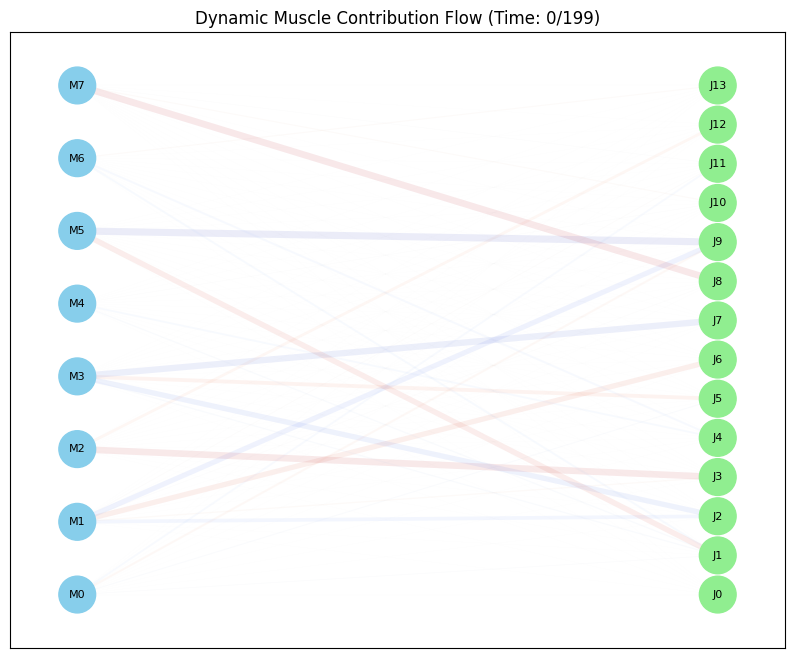

Visualization finished.


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import networkx as nx
# Import this if you need to load .mat files
# from scipy.io import loadmat

# --- Simulation Parameters (Replace with your actual data dimensions) ---
NUM_TIME_STEPS = 200  # Number of time steps to animate (reduced for speed)
NUM_MUSCLES = 8
NUM_JOINTS = 14
MAX_SAMPLES_PER_CELL = 4000 # Max samples in the original data

# --- Data Loading Placeholder (Replace with your .mat loading) ---
# Example:
# data = loadmat('your_data_file.mat')
# # Assuming you select one specific trial and task cell, e.g., trial 0, task 0
# trial_idx, task_idx = 0, 0
# sEMG_data = data['dsfilt_emg'][trial_idx, task_idx][:NUM_TIME_STEPS, :] # Shape: (NUM_TIME_STEPS, NUM_MUSCLES)
# angle_data = data['joint_angles'][trial_idx, task_idx][:NUM_TIME_STEPS, :] # Shape: (NUM_TIME_STEPS, NUM_JOINTS)
# --- End Data Loading Placeholder ---

# --- Simulate Data (Remove this section when using real data) ---
print("Simulating data...")
# Simulate sEMG data (random walk style)
sEMG_data = np.cumsum(np.random.randn(NUM_TIME_STEPS, NUM_MUSCLES) * 0.1, axis=0)
sEMG_data = (sEMG_data - np.mean(sEMG_data, axis=0)) / np.std(sEMG_data, axis=0) # Normalize

# Simulate angle data (random walk style, loosely related to sEMG for demo)
angle_data = np.cumsum(np.random.randn(NUM_TIME_STEPS, NUM_JOINTS) * 0.05, axis=0)
# --- End Simulate Data ---

# --- AI Model Prediction Placeholder ---
# Here you would typically feed sEMG_data into your trained model
# predicted_angles = your_ai_model.predict(sEMG_data)
# For this example, we'll just use the simulated angle_data as the "prediction"
predicted_angles = angle_data
# --- End AI Model Prediction Placeholder ---


# --- XAI Contribution Calculation Placeholder ---
# This is the CRITICAL part you need to implement.
# You need an XAI method (SHAP, LIME, Integrated Gradients, Attention, etc.)
# applied to your model to get the contribution of each muscle `m`
# to each joint angle `j` at each time step `t`.
# The result should be a numpy array of shape: (NUM_TIME_STEPS, NUM_MUSCLES, NUM_JOINTS)
# Positive values might mean excitation, negative inhibition.

print("Simulating XAI contributions...")
# Simulate contributions: random fluctuations, some muscles influence some joints more
np.random.seed(42) # for reproducibility
xai_contributions = np.random.randn(NUM_TIME_STEPS, NUM_MUSCLES, NUM_JOINTS) * 0.5

# Make contributions sparser and more structured (example)
mask = np.random.rand(NUM_MUSCLES, NUM_JOINTS) > 0.7 # Only ~30% connections active
xai_contributions *= mask[np.newaxis, :, :]
# Add some temporal structure (e.g., sine wave modulation)
time_modulation = np.sin(np.linspace(0, 4 * np.pi, NUM_TIME_STEPS))[:, np.newaxis, np.newaxis]
xai_contributions *= (1 + time_modulation * 0.5)
print(f"Simulated XAI contributions shape: {xai_contributions.shape}")
# --- End XAI Contribution Calculation Placeholder ---


# --- Visualization Setup ---
print("Setting up visualization...")

# Muscle and Joint Names (Customize as needed)
muscle_names = [f'M{i}' for i in range(NUM_MUSCLES)] # e.g., ['APL', 'FCR', ...]
joint_names = [f'J{i}' for i in range(NUM_JOINTS)]   # e.g., ['Thumb1', 'Thumb2', ...]

# Create Graph
G = nx.Graph()
nodes = muscle_names + joint_names
G.add_nodes_from(nodes)

# Define Node Positions (Customize layout)
pos = {}
muscle_x = 0
joint_x = 1
for i, name in enumerate(muscle_names):
    pos[name] = (muscle_x, i)
for i, name in enumerate(joint_names):
    pos[name] = (joint_x, i * (NUM_MUSCLES - 1) / (NUM_JOINTS - 1)) # Spread joints vertically

# Add edges for all possible connections (initially invisible/thin)
edges = []
for m_idx, m_name in enumerate(muscle_names):
    for j_idx, j_name in enumerate(joint_names):
        G.add_edge(m_name, j_name, weight=0) # Add edge with initial weight
        edges.append((m_name, j_name))

# --- Matplotlib Figure Setup ---
fig, ax = plt.subplots(figsize=(10, 8))
plt.title("Dynamic Muscle Contribution Flow (Time: 0)")

# Draw nodes
node_colors = ['skyblue'] * NUM_MUSCLES + ['lightgreen'] * NUM_JOINTS
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=700, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)

# Prepare edge drawing (store edge collection for updates)
edge_collection = nx.draw_networkx_edges(G, pos, width=1, edge_color='gray', alpha=0.1, ax=ax)

# --- Animation Function ---
def update(frame):
    """Updates the plot for each animation frame (time step)."""
    contributions_at_t = xai_contributions[frame, :, :] # Shape: (NUM_MUSCLES, NUM_JOINTS)

    # Normalize contributions for visualization (e.g., absolute value for width)
    # You might want different scaling (linear, log) or color mapping
    abs_contributions = np.abs(contributions_at_t)
    max_abs_contribution = np.max(abs_contributions) if np.max(abs_contributions) > 0 else 1
    scaled_widths = (abs_contributions / max_abs_contribution) * 5.0 + 0.1 # Min width 0.1, Max width 5.1

    # Map contributions to colors (e.g., blue for negative/inhibitory, red for positive/excitatory)
    # Normalize contributions between -1 and 1 for colormap
    max_val = np.max(np.abs(contributions_at_t)) if np.max(np.abs(contributions_at_t)) > 0 else 1
    norm_contributions = contributions_at_t / max_val
    colors = plt.cm.coolwarm(norm_contributions.flatten() * 0.5 + 0.5) # Map [-1, 1] -> [0, 1] for colormap

    edge_widths = []
    edge_colors = []
    edge_alphas = [] # Control visibility based on contribution strength

    edge_idx = 0
    for m_idx in range(NUM_MUSCLES):
        for j_idx in range(NUM_JOINTS):
            width = scaled_widths[m_idx, j_idx]
            color = colors[edge_idx, :]
            alpha = min(max(abs_contributions[m_idx, j_idx] / max_abs_contribution * 2.0, 0.1), 1.0) # Make stronger contributions more opaque

            edge_widths.append(width)
            edge_colors.append(color)
            edge_alphas.append(alpha)
            edge_idx += 1

    # Update edge properties directly
    edge_collection.set_linewidths(edge_widths)
    edge_collection.set_edgecolors(edge_colors)
    # Note: set_alpha doesn't work directly on LineCollection, need to update colors with alpha
    edge_colors_with_alpha = [(r, g, b, a) for (r, g, b, _), a in zip(edge_colors, edge_alphas)]
    edge_collection.set_edgecolors(edge_colors_with_alpha)


    # Update title with current time step
    ax.set_title(f"Dynamic Muscle Contribution Flow (Time: {frame}/{NUM_TIME_STEPS-1})")

    # Return the modified artists (important for blitting)
    return edge_collection,

# --- Create and Run Animation ---
print("Creating animation...")
# Note: interval is delay between frames in ms. blit=True speeds up rendering.
ani = animation.FuncAnimation(fig, update, frames=NUM_TIME_STEPS,
                              interval=50, blit=True, repeat=False)

# To save the animation (requires ffmpeg or other writer)
# print("Saving animation...")
# ani.save('muscle_contribution_flow.mp4', writer='ffmpeg', fps=15)
# print("Animation saved.")

# To display the animation
plt.show()
print("Visualization finished.")



In [8]:
# %% Imports
import numpy as np
import scipy.io
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import os
# from tqdm.notebook import tqdm # Use 'tqdm' if not in a notebook
from tqdm import tqdm # Standard tqdm for scripts
import warnings
import shap # Import SHAP
import gc # Garbage collector

# --- Sklearn Imports ---
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
# Regression Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor # Important for SVR
from sklearn.base import clone # To get fresh model instances

# Filter warnings during SHAP calculations if needed
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning) # Ignore potential RuntimeWarnings from pearsonr/std dev


# %% Configuration
DATA_DIR = '.'  # Directory containing s1_full.mat, s2_full.mat, etc.
SUBJECT_FILES = [f's{i}_full.mat' for i in range(1, 6)]
N_SUBJECTS = len(SUBJECT_FILES)
OUTPUT_DIR = 'results' # Directory to save plots

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Windowing Parameters
WINDOW_SIZE = 200
STRIDE = 50  # How many data points the window slides forward each step

# EMG Channel Names (Assuming the order given previously)
EMG_CHANNELS = ['APL', 'FCR', 'FDS', 'FDP', 'ED', 'EI', 'ECU', 'ECR']
N_CHANNELS = len(EMG_CHANNELS)

# %% Feature Extraction Functions

# Define the list of base feature names BEFORE the function
BASE_FEATURE_NAMES = ['MAV', 'RMS', 'WL', 'ZC', 'SSC', 'VAR', 'IEMG', 'WAMP']
N_BASE_FEATURES = len(BASE_FEATURE_NAMES)

def calculate_td_features(window_data, wamp_threshold=1e-4):
    """Calculates time-domain features for a single window across all channels.

    Args:
        window_data (np.ndarray): Data within a window (WINDOW_SIZE x N_CHANNELS).
        wamp_threshold (float): Threshold for Willison Amplitude calculation.

    Returns:
        np.ndarray: A flat array containing features for all channels.
                    Order follows BASE_FEATURE_NAMES for each channel sequentially.
    """
    n_channels = window_data.shape[1]
    features = np.zeros(n_channels * N_BASE_FEATURES) # Pre-allocate array

    # Set thresholds (can be tuned)
    zc_threshold = 1e-5 # To avoid noise detection for zero crossings
    ssc_threshold = 1e-5 # Threshold for slope sign change detection

    for i in range(n_channels):
        channel_data = window_data[:, i]
        base_idx = i * N_BASE_FEATURES

        # Pre-calculate diff for efficiency
        diff_data = np.diff(channel_data)
        abs_diff_data = np.abs(diff_data)

        # 1. Mean Absolute Value (MAV)
        features[base_idx + 0] = np.mean(np.abs(channel_data))

        # 2. Root Mean Square (RMS)
        features[base_idx + 1] = np.sqrt(np.mean(channel_data**2))

        # 3. Waveform Length (WL)
        features[base_idx + 2] = np.sum(abs_diff_data)

        # 4. Zero Crossings (ZC)
        features[base_idx + 3] = np.sum(((channel_data[:-1] * channel_data[1:]) < 0) &
                                        (np.abs(channel_data[:-1] - channel_data[1:]) >= zc_threshold))

        # 5. Slope Sign Changes (SSC)
        # Check if diff_data has enough elements for SSC calculation
        if diff_data.size > 1:
             features[base_idx + 4] = np.sum(((diff_data[:-1] * diff_data[1:]) < 0) &
                                             ((np.abs(diff_data[:-1]) >= ssc_threshold) |
                                              (np.abs(diff_data[1:]) >= ssc_threshold)))
        # else: SSC is 0 if not enough points

        # 6. Variance (VAR)
        features[base_idx + 5] = np.var(channel_data)

        # 7. Integrated EMG (IEMG)
        features[base_idx + 6] = np.sum(np.abs(channel_data))

        # 8. Willison Amplitude (WAMP)
        features[base_idx + 7] = np.sum(abs_diff_data >= wamp_threshold)

    return features

# Generate full feature names list (e.g., MAV_APL, RMS_APL, ..., WAMP_ECR)
FEATURE_NAMES = [f"{feat}_{chan}" for chan in EMG_CHANNELS for feat in BASE_FEATURE_NAMES]
N_TOTAL_FEATURES = N_CHANNELS * N_BASE_FEATURES

def create_feature_matrix(emg_data, window_size, stride):
    """Creates feature matrix and corresponding target indices from EMG data."""
    n_samples, n_channels_data = emg_data.shape
    if n_channels_data != N_CHANNELS:
         raise ValueError(f"Data has {n_channels_data} channels, expected {N_CHANNELS}")

    # Calculate the number of windows
    num_windows = (n_samples - window_size) // stride + 1
    if num_windows <= 0:
         return np.empty((0, N_TOTAL_FEATURES)), np.empty((0,), dtype=int)

    # Pre-allocate arrays
    features_array = np.zeros((num_windows, N_TOTAL_FEATURES))
    target_indices = np.zeros(num_windows, dtype=int)
    window_idx = 0

    for i in range(0, n_samples - window_size + 1, stride):
        window = emg_data[i : i + window_size, :]
        features_array[window_idx, :] = calculate_td_features(window) # WAMP threshold uses default
        # Target corresponds to the *end* of the window
        target_indices[window_idx] = i + window_size - 1
        window_idx += 1

    return features_array, target_indices

# %% Data Loading and Preprocessing

all_subject_data = []
print("Loading and preprocessing data...")

for subject_file in tqdm(SUBJECT_FILES, desc="Processing Subjects"):
    file_path = os.path.join(DATA_DIR, subject_file)
    # Reset subject-specific lists for each file
    subject_emg = []
    subject_angles = []
    try:
        if not os.path.exists(file_path):
            print(f"\nWarning: File not found - {file_path}. Skipping.")
            continue
        mat_data = scipy.io.loadmat(file_path)
    except Exception as e:
        print(f"\nError loading {file_path}: {e}. Skipping.")
        continue

    if 'dsfilt_emg' not in mat_data or 'joint_angles' not in mat_data:
        print(f"\nWarning: Missing 'dsfilt_emg' or 'joint_angles' in {subject_file}. Skipping.")
        continue

    dsfilt_emg_cell = mat_data['dsfilt_emg']
    joint_angles_cell = mat_data['joint_angles']

    # Data validation flags for the current subject
    valid_subject_data_found = False
    try:
        num_trials, num_tasks = dsfilt_emg_cell.shape
        for trial in range(num_trials):
            for task in range(num_tasks):
                # Check if the cell content is a numpy array and has data
                if isinstance(dsfilt_emg_cell[trial, task], np.ndarray) and \
                   isinstance(joint_angles_cell[trial, task], np.ndarray) and \
                   dsfilt_emg_cell[trial, task].size > 0 and \
                   joint_angles_cell[trial, task].size > 0:

                    emg_segment = np.asarray(dsfilt_emg_cell[trial, task], dtype=np.float64)
                    angle_segment = np.asarray(joint_angles_cell[trial, task], dtype=np.float64)

                    # Perform rigorous checks
                    if emg_segment.ndim == 2 and angle_segment.ndim == 2 and \
                       emg_segment.shape[0] == angle_segment.shape[0] and \
                       emg_segment.shape[1] == N_CHANNELS and \
                       angle_segment.shape[1] == 14 and \
                       emg_segment.shape[0] >= WINDOW_SIZE:
                         subject_emg.append(emg_segment)
                         subject_angles.append(angle_segment)
                         valid_subject_data_found = True # Mark that we found usable data
                    # else: # Optional detailed logging for skipped segments
                    #    print(f"\nDebug: Skipping segment T{trial+1},t{task+1} in {subject_file}. EMG shape {emg_segment.shape}, Angle shape {angle_segment.shape}, Min Length {WINDOW_SIZE}")

    except Exception as e:
        print(f"\nError processing cells in {subject_file}: {e}")
        # Continue to next subject if cell processing fails for this one

    # Process subject only if valid segments were found and appended
    if not valid_subject_data_found:
         print(f"\nWarning: No valid data segments found meeting criteria for {subject_file}. Skipping subject.")
         continue # Skip to next subject

    # Concatenate valid segments for the subject
    try:
        subject_emg_full = np.concatenate(subject_emg, axis=0)
        subject_angles_full = np.concatenate(subject_angles, axis=0)
        # Clear lists to free memory
        del subject_emg
        del subject_angles
        gc.collect()
    except ValueError as e:
        print(f"\nError concatenating segments for {subject_file}: {e}. Check channel/angle counts consistency. Skipping subject.")
        continue # Skip subject if concatenation fails

    # Create features and align targets for the subject
    try:
        X_subject, target_idx_subject = create_feature_matrix(
            subject_emg_full, WINDOW_SIZE, STRIDE
        )
        # Clear large arrays no longer needed
        del subject_emg_full
        gc.collect()

        # Ensure target indices are valid before slicing
        if target_idx_subject.size > 0 and np.max(target_idx_subject) < subject_angles_full.shape[0]:
             y_subject = subject_angles_full[target_idx_subject, :]
             del subject_angles_full # Clear original angles
             gc.collect()

             # Final check on shapes before appending
             if X_subject.shape[0] > 0 and y_subject.shape[0] == X_subject.shape[0]:
                 all_subject_data.append({'X': X_subject, 'y': y_subject, 'id': subject_file})
                 print(f"Successfully processed {subject_file}: Features {X_subject.shape}, Targets {y_subject.shape}")
             else:
                 print(f"\nWarning: Feature/target count mismatch after indexing for {subject_file}. X:{X_subject.shape}, y:{y_subject.shape}. Skipping subject.")
                 del X_subject, y_subject # Clean up
                 gc.collect()
        else:
            print(f"\nWarning: No features generated or invalid target indices for {subject_file} (Data length {subject_angles_full.shape[0]} vs window/stride). Skipping subject.")
            del subject_angles_full # Clean up
            if 'X_subject' in locals(): del X_subject
            gc.collect()

    except ValueError as e: # Catch errors from create_feature_matrix (e.g., channel mismatch)
        print(f"\nError creating features for {subject_file}: {e}. Skipping subject.")
        if 'subject_angles_full' in locals(): del subject_angles_full
        gc.collect()
    except Exception as e: # Catch any other unexpected errors during feature/target creation
        print(f"\nUnexpected error processing features/targets for {subject_file}: {e}. Skipping subject.")
        if 'subject_angles_full' in locals(): del subject_angles_full
        if 'X_subject' in locals(): del X_subject
        if 'y_subject' in locals(): del y_subject
        gc.collect()


# Final check on number of subjects processed
if len(all_subject_data) < N_SUBJECTS:
    print(f"\nWarning: Initially found {N_SUBJECTS} files, but only successfully processed {len(all_subject_data)} subjects.")
N_SUBJECTS = len(all_subject_data) # Update N_SUBJECTS to actual processed count

if N_SUBJECTS < 2:
    print("\nError: Need at least two successfully processed subjects for Leave-One-Subject-Out cross-validation. Exiting.")
    exit() # Exit if not enough subjects for LOSO
else:
    print(f"\nProceeding with {N_SUBJECTS} subjects for LOSO.")
    # %% LOSO Cross-Validation

    # Define base models (will be wrapped or cloned)
    base_models = {
        "Linear Regression": LinearRegression(),
        "Ridge": Ridge(alpha=1.0),
        "KNN": KNeighborsRegressor(n_neighbors=7),
        # SVR is often slow, especially with many features/samples.
        # "SVR_linear": MultiOutputRegressor(SVR(kernel='linear', C=1.0, cache_size=500)), # Keep commented if slow
        # "SVR_rbf": MultiOutputRegressor(SVR(kernel='rbf', C=1.0, gamma='scale', cache_size=500)), # Keep commented if slow
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15, min_samples_split=5),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42, max_depth=5)
    }

    # Store results: results[model_name] = {'rmse': [], 'r2': [], 'cc': []}
    results = {name: {'rmse': [], 'r2': [], 'cc': []} for name in base_models.keys()}
    try:
        n_outputs = all_subject_data[0]['y'].shape[1] # Should be 14
    except IndexError:
        print("Error: all_subject_data is empty or malformed after preprocessing. Cannot determine number of outputs.")
        exit()


    loso = LeaveOneOut()
    subject_indices = list(range(N_SUBJECTS))

    print("\nStarting LOSO Cross-Validation...")
    for fold_num, (train_idx, test_idx) in enumerate(tqdm(loso.split(subject_indices), total=N_SUBJECTS, desc="LOSO Folds")):
        test_subject_index = subject_indices[test_idx[0]]
        train_subject_indices = [subject_indices[i] for i in train_idx]
        test_subject_id = all_subject_data[test_subject_index]['id']
        # print(f"  Fold {fold_num+1}/{N_SUBJECTS}: Testing on {test_subject_id}") # Less verbose output

        # --- Prepare Train/Test Data for this Fold ---
        # Access data safely
        try:
            X_train_list = [all_subject_data[i]['X'] for i in train_subject_indices]
            y_train_list = [all_subject_data[i]['y'] for i in train_subject_indices]
            X_test = all_subject_data[test_subject_index]['X']
            y_test = all_subject_data[test_subject_index]['y']
        except Exception as e:
             print(f"\nError accessing data for fold {fold_num+1}: {e}. Skipping fold.")
             for name in base_models.keys(): results[name]['rmse'].append(np.nan); results[name]['r2'].append(np.nan); results[name]['cc'].append(np.nan)
             continue # Skip to next fold

        # Check for empty test set (could happen if subject processing failed silently)
        if X_test.shape[0] == 0:
            print(f"\nWarning: Empty test set for {test_subject_id} in fold {fold_num+1}. Skipping fold.")
            for name in base_models.keys(): results[name]['rmse'].append(np.nan); results[name]['r2'].append(np.nan); results[name]['cc'].append(np.nan)
            continue

        # Concatenate training data
        try:
            X_train = np.concatenate(X_train_list, axis=0)
            y_train = np.concatenate(y_train_list, axis=0)
            del X_train_list, y_train_list # Free memory
            gc.collect()
        except ValueError as e:
             print(f"\nError concatenating training data for fold {fold_num+1}: {e}. Skipping fold.")
             for name in base_models.keys(): results[name]['rmse'].append(np.nan); results[name]['r2'].append(np.nan); results[name]['cc'].append(np.nan)
             continue

        # Check for empty training set
        if X_train.shape[0] == 0:
            print(f"\nWarning: Empty training set in fold {fold_num+1}. Skipping fold.")
            for name in base_models.keys(): results[name]['rmse'].append(np.nan); results[name]['r2'].append(np.nan); results[name]['cc'].append(np.nan)
            continue

        # --- Feature Scaling ---
        scaler = StandardScaler()
        try:
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            del X_train # Free memory
            gc.collect()
        except Exception as e:
            print(f"\nError during scaling for fold {fold_num+1}: {e}. Skipping fold.")
            for name in base_models.keys(): results[name]['rmse'].append(np.nan); results[name]['r2'].append(np.nan); results[name]['cc'].append(np.nan)
            # Clean up potentially large arrays if scaling failed mid-way
            if 'X_train_scaled' in locals(): del X_train_scaled
            if 'X_test_scaled' in locals(): del X_test_scaled
            gc.collect()
            continue

        # --- Train and Evaluate Models for this Fold ---
        for name, base_model in base_models.items():
            model = clone(base_model) # Use a fresh clone for each fold
            try:
                # print(f"    Training {name}...") # Optional verbose logging
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)

                # --- Metric Calculation ---
                # RMSE
                fold_mse = mean_squared_error(y_test, y_pred)
                fold_rmse = np.sqrt(fold_mse) if fold_mse >= 0 else np.nan # Handle potential negative MSE? (unlikely)

                # R2 Score (Coefficient of Determination)
                # 'variance_weighted' averages R2 scores per output, weighted by the variance of each output.
                # This is standard but means outputs with low variance contribute less to the average.
                # Use 'raw_values' to get R2 per output for detailed analysis if needed.
                fold_r2_weighted = r2_score(y_test, y_pred, multioutput='variance_weighted')

                # Pearson Correlation Coefficient (CC)
                fold_cc_per_angle = []
                if y_test.shape[0] > 1 and y_pred.shape[0] > 1: # Need >1 sample
                    for i in range(n_outputs):
                        # Check for non-zero std dev before calculating correlation
                        if np.std(y_test[:, i]) > 1e-6 and np.std(y_pred[:, i]) > 1e-6:
                            # pearsonr returns (correlation, p-value)
                            cc_val, _ = pearsonr(y_test[:, i], y_pred[:, i])
                            # Handle potential NaN correlation if inputs are constant despite std check (rare)
                            fold_cc_per_angle.append(cc_val if not np.isnan(cc_val) else 0.0)
                        else:
                           # If variance is near zero, correlation is ill-defined or trivial.
                           # Assign 1.0 if prediction perfectly matches a constant target, else 0.0
                           fold_cc_per_angle.append(1.0 if np.allclose(y_test[:, i], y_pred[:, i]) else 0.0)
                else: # If only one sample, correlation is undefined
                     fold_cc_per_angle = [np.nan] * n_outputs

                fold_cc_mean = np.nanmean(fold_cc_per_angle) # Average CC, ignoring NaNs

                # Store results for this fold
                results[name]['rmse'].append(fold_rmse)
                results[name]['r2'].append(fold_r2_weighted) # Store the weighted R2
                results[name]['cc'].append(fold_cc_mean if not np.isnan(fold_cc_mean) else 0.0) # Avoid NaN

                # Clean up predictions
                del y_pred
                gc.collect()

            except Exception as e:
                print(f"\n      Error training/predicting with {name} in fold {fold_num+1} ({test_subject_id}): {e}")
                results[name]['rmse'].append(np.nan); results[name]['r2'].append(np.nan); results[name]['cc'].append(np.nan)
            finally:
                 # Ensure model object is deleted after use in fold
                 del model
                 gc.collect()

        # Clean up scaled data for the fold
        del X_train_scaled, X_test_scaled, y_train, y_test
        gc.collect()


    # %% Aggregate and Print Results
    print("\n--- LOSO Cross-Validation Results ---")
    print(f"{'Model':<20} | {'Mean RMSE':<12} | {'Std RMSE':<10} | {'Mean R2':<10} | {'Std R2':<10} | {'Mean CC':<10} | {'Std CC':<10}")
    print("-" * 85)

    avg_results = {}
    best_model_name = None
    best_rmse = float('inf')

    for name in base_models.keys():
        # Convert lists to numpy arrays for nan-aware calculations
        rmse_vals = np.array(results[name]['rmse'])
        r2_vals = np.array(results[name]['r2']) # These are the variance-weighted R2 scores
        cc_vals = np.array(results[name]['cc'])

        # Calculate mean and std, ignoring NaNs from potential errors
        mean_rmse = np.nanmean(rmse_vals)
        std_rmse = np.nanstd(rmse_vals)
        mean_r2 = np.nanmean(r2_vals)
        std_r2 = np.nanstd(r2_vals)
        mean_cc = np.nanmean(cc_vals)
        std_cc = np.nanstd(cc_vals)

        avg_results[name] = {'rmse': mean_rmse, 'r2': mean_r2, 'cc': mean_cc,
                             'rmse_std': std_rmse, 'r2_std': std_r2, 'cc_std': std_cc}

        # Track best model based on lowest mean RMSE
        if not np.isnan(mean_rmse) and mean_rmse < best_rmse:
             best_rmse = mean_rmse
             best_model_name = name

        # Format for printing, handling potential NaNs in results
        mean_rmse_str = f"{mean_rmse:<12.4f}" if not np.isnan(mean_rmse) else "NaN         "
        std_rmse_str = f"{std_rmse:<10.4f}" if not np.isnan(std_rmse) else "NaN       "
        mean_r2_str = f"{mean_r2:<10.4f}" if not np.isnan(mean_r2) else "NaN       "
        std_r2_str = f"{std_r2:<10.4f}" if not np.isnan(std_r2) else "NaN       "
        mean_cc_str = f"{mean_cc:<10.4f}" if not np.isnan(mean_cc) else "NaN       "
        std_cc_str = f"{std_cc:<10.4f}" if not np.isnan(std_cc) else "NaN       "
        print(f"{name:<20} | {mean_rmse_str} | {std_rmse_str} | {mean_r2_str} | {std_r2_str} | {mean_cc_str} | {std_cc_str}")

    # %% Visualization (Saving Plots)
    print("\nGenerating and saving performance plots...")
    model_names_plot = list(avg_results.keys())
    # Filter out models that might have all NaN results before plotting
    valid_models_plot = [name for name in model_names_plot if not np.isnan(avg_results[name]['rmse'])]

    if not valid_models_plot:
        print("No valid model results to plot (all results might be NaN).")
    else:
        plot_model_names = valid_models_plot
        mean_rmse = [avg_results[name]['rmse'] for name in plot_model_names]
        std_rmse = [avg_results[name]['rmse_std'] for name in plot_model_names]
        mean_r2 = [avg_results[name]['r2'] for name in plot_model_names] # Plotting avg variance-weighted R2
        std_r2 = [avg_results[name]['r2_std'] for name in plot_model_names]
        mean_cc = [avg_results[name]['cc'] for name in plot_model_names]
        std_cc = [avg_results[name]['cc_std'] for name in plot_model_names]

        x_pos = np.arange(len(plot_model_names))
        fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True)
        fig.suptitle('Model Performance Comparison (LOSO Avg +/- Std Dev)', fontsize=16)

        # RMSE Plot
        axs[0].bar(x_pos, mean_rmse, yerr=std_rmse, align='center', alpha=0.7, ecolor='black', capsize=10)
        axs[0].set_ylabel('Mean RMSE')
        axs[0].set_title('Average Root Mean Squared Error (Lower is Better)')
        axs[0].grid(axis='y', linestyle='--')

        # R2 Plot (Variance-Weighted Average)
        axs[1].bar(x_pos, mean_r2, yerr=std_r2, align='center', alpha=0.7, ecolor='black', capsize=10)
        axs[1].set_ylabel('Mean R² Score (Var. Weighted)')
        axs[1].set_title('Average Coefficient of Determination (R²) (Higher is Better)')
        axs[1].grid(axis='y', linestyle='--'); axs[1].axhline(0, color='grey', lw=0.8, linestyle='--')
        # Adjust y-limits carefully, considering potential negative R2 and std dev
        min_r2_plot = np.nanmin(np.array(mean_r2) - np.array(std_r2)) if len(mean_r2) > 0 else -0.1
        axs[1].set_ylim(bottom=min(-0.05, min_r2_plot - 0.1)) # Ensure 0 is visible, leave room for error bars

        # CC Plot
        axs[2].bar(x_pos, mean_cc, yerr=std_cc, align='center', alpha=0.7, ecolor='black', capsize=10)
        axs[2].set_ylabel('Mean Pearson CC')
        axs[2].set_title('Average Pearson Correlation Coefficient (Higher is Better)')
        axs[2].set_xticks(x_pos)
        axs[2].set_xticklabels(plot_model_names, rotation=45, ha='right')
        axs[2].grid(axis='y', linestyle='--'); axs[2].axhline(0, color='grey', lw=0.8, linestyle='--')
        min_cc_plot = np.nanmin(np.array(mean_cc) - np.array(std_cc)) if len(mean_cc) > 0 else -0.1
        axs[2].set_ylim(bottom=min(-0.05, min_cc_plot - 0.1)) # Ensure 0 is visible

        plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout
        plot_filename = os.path.join(OUTPUT_DIR, "model_performance_comparison.png")
        try:
            plt.savefig(plot_filename, bbox_inches='tight', dpi=150) # Save figure
            print(f"Performance comparison plot saved to {plot_filename}")
        except Exception as e:
            print(f"Error saving performance plot: {e}")
        plt.close(fig) # Close figure to free memory
        gc.collect()

    # %% SHAP Analysis (on the best model trained on all data)
    # Ensure we have a best model and data before proceeding
    if best_model_name and all_subject_data:
        print(f"\nStarting SHAP analysis for the best model: {best_model_name} (based on lowest avg RMSE)")

        # 1. Prepare Full Dataset
        X_all_list = [data['X'] for data in all_subject_data]
        y_all_list = [data['y'] for data in all_subject_data]
        # Clear original list to save memory before concatenating
        del all_subject_data
        gc.collect()
        try:
            X_all = np.concatenate(X_all_list, axis=0)
            y_all = np.concatenate(y_all_list, axis=0)
            del X_all_list, y_all_list # Free memory
            gc.collect()
            print(f"Full dataset shape for SHAP: X={X_all.shape}, y={y_all.shape}")
        except ValueError as e:
            print(f"Error concatenating full dataset for SHAP: {e}. Skipping SHAP.")
            best_model_name = None # Prevent further SHAP steps
        except Exception as e: # Catch other potential errors
             print(f"Unexpected error preparing full dataset for SHAP: {e}. Skipping SHAP.")
             best_model_name = None

        # Proceed only if full dataset created successfully
        if best_model_name and 'X_all' in locals() and 'y_all' in locals():
             # 2. Scale Full Dataset
             scaler_all = StandardScaler()
             try:
                 X_all_scaled = scaler_all.fit_transform(X_all)
                 del X_all # Free memory
                 gc.collect()
             except Exception as e:
                 print(f"Error scaling full dataset: {e}. Skipping SHAP.")
                 best_model_name = None
                 if 'X_all' in locals(): del X_all
                 if 'y_all' in locals(): del y_all
                 gc.collect()


             # 3. Train Best Model on Full Dataset
             if best_model_name:
                 print(f"Training {best_model_name} on the full dataset...")
                 # Get a fresh clone of the best model configuration
                 final_model = clone(base_models[best_model_name])
                 try:
                     final_model.fit(X_all_scaled, y_all)
                     del y_all # Free memory
                     gc.collect()
                 except Exception as e:
                     print(f"Error training final model {best_model_name}: {e}. Skipping SHAP.")
                     best_model_name = None
                     # Clean up scaled data if model training failed
                     if 'X_all_scaled' in locals(): del X_all_scaled
                     if 'y_all' in locals(): del y_all
                     gc.collect()


             # 4. Initialize SHAP Explainer & Calculate Values
             if best_model_name:
                 print("Calculating SHAP values (this may take time)...")
                 explainer = None
                 shap_values = None # Use 'shap_values', not 'shap_values_list'
                 X_shap_subset = X_all_scaled # Default to using all scaled data

                 try:
                     # Select appropriate explainer
                     model_instance_for_shap = final_model # Use the trained final_model
                     if isinstance(model_instance_for_shap, (RandomForestRegressor, GradientBoostingRegressor)):
                         explainer = shap.TreeExplainer(model_instance_for_shap, feature_perturbation="interventional", model_output="raw")
                         # For TreeExplainer, shap_values directly on data
                         # Use a subset if dataset is very large to speed up calculation/plotting
                         n_shap_subset = min(2000, X_all_scaled.shape[0])
                         if n_shap_subset < X_all_scaled.shape[0]:
                              print(f"Using subset of {n_shap_subset} samples for Tree SHAP calculation.")
                              X_shap_subset = shap.sample(X_all_scaled, n_shap_subset, random_state=42)
                         else:
                              X_shap_subset = X_all_scaled
                         shap_values = explainer.shap_values(X_shap_subset)

                     elif isinstance(model_instance_for_shap, (LinearRegression, Ridge)):
                          # LinearExplainer needs data for correlations
                          explainer = shap.LinearExplainer(model_instance_for_shap, X_all_scaled)
                          X_shap_subset = X_all_scaled # Usually fast enough for all data
                          shap_values = explainer.shap_values(X_shap_subset)

                     elif isinstance(model_instance_for_shap, KNeighborsRegressor):
                          # KernelExplainer for KNN - potentially very slow!
                          n_background_samples = min(100, X_all_scaled.shape[0]) # Background samples
                          n_shap_samples = min(500, X_all_scaled.shape[0]) # Samples to explain
                          print(f"Using KernelExplainer for KNN with {n_background_samples} background samples, explaining {n_shap_samples} instances.")
                          X_background = shap.kmeans(X_all_scaled, n_background_samples, random_state=42)
                          explainer = shap.KernelExplainer(model_instance_for_shap.predict, X_background)
                          X_shap_subset = X_all_scaled[:n_shap_samples, :] # Explain first N samples
                          shap_values = explainer.shap_values(X_shap_subset)

                     # Add elif for SVR if uncommented earlier
                     # elif isinstance(model_instance_for_shap, MultiOutputRegressor) and isinstance(model_instance_for_shap.estimator, SVR):
                     #      # KernelExplainer for SVR - potentially very slow!
                     #      n_background_samples = min(100, X_all_scaled.shape[0])
                     #      n_shap_samples = min(500, X_all_scaled.shape[0])
                     #      print(f"Using KernelExplainer for SVR with {n_background_samples} background samples, explaining {n_shap_samples} instances.")
                     #      X_background = shap.kmeans(X_all_scaled, n_background_samples, random_state=42)
                     #      explainer = shap.KernelExplainer(model_instance_for_shap.predict, X_background)
                     #      X_shap_subset = X_all_scaled[:n_shap_samples, :]
                     #      shap_values = explainer.shap_values(X_shap_subset)

                     else:
                          print(f"SHAP analysis not automatically configured for model type: {type(model_instance_for_shap)}. Skipping.")
                          best_model_name = None # Mark SHAP as skipped


                     # 5. Generate and Save SHAP Summary Plot (Global Importance)
                     if shap_values is not None:
                         print("Generating SHAP summary plot...")
                         # Check if shap_values is a list (multi-output) or single array
                         if isinstance(shap_values, list):
                             # For multi-output, plot average impact across outputs
                             # Use shap.Explanation object for better plotting support
                             exp = shap.Explanation(values=shap_values,
                                                    base_values=explainer.expected_value, # Get expected values if available
                                                    data=X_shap_subset,
                                                    feature_names=FEATURE_NAMES)
                             # Plot mean absolute SHAP value across outputs using pooled=True
                             shap.summary_plot(exp.mean(axis=0), # Average SHAP values across samples
                                               features=X_shap_subset, # Pass the data used for SHAP calculation
                                               feature_names=FEATURE_NAMES,
                                               plot_type="bar", # Bar plot for global importance
                                               max_display=20, # Show top N features
                                               show=False)
                         else: # Single output case (or models where explainer returns single array)
                              shap.summary_plot(shap_values,
                                                features=X_shap_subset,
                                                feature_names=FEATURE_NAMES,
                                                plot_type="bar",
                                                max_display=20,
                                                show=False)

                         shap_plot_filename = os.path.join(OUTPUT_DIR, f"shap_summary_{best_model_name.replace(' ', '_')}.png")
                         fig = plt.gcf() # Get current figure
                         fig.set_size_inches(10, 12) # Adjust figure size
                         try:
                              plt.savefig(shap_plot_filename, bbox_inches='tight', dpi=150)
                              print(f"SHAP summary plot saved to {shap_plot_filename}")
                         except Exception as e:
                              print(f"Error saving SHAP plot: {e}")
                         plt.close(fig) # Close figure
                         gc.collect()

                         # Optional: Beeswarm plot for more detail (can be slow/dense)
                         # print("Generating SHAP beeswarm plot...")
                         # shap.summary_plot(shap_values[0] if isinstance(shap_values, list) else shap_values,
                         #                   features=X_shap_subset,
                         #                   feature_names=FEATURE_NAMES,
                         #                   plot_type="dot", # Beeswarm
                         #                   max_display=20,
                         #                   show=False)
                         # shap_beeswarm_filename = os.path.join(OUTPUT_DIR, f"shap_beeswarm_{best_model_name.replace(' ', '_')}.png")
                         # fig_bee = plt.gcf()
                         # fig_bee.set_size_inches(10, 12)
                         # try:
                         #      plt.savefig(shap_beeswarm_filename, bbox_inches='tight', dpi=150)
                         #      print(f"SHAP beeswarm plot saved to {shap_beeswarm_filename}")
                         # except Exception as e:
                         #      print(f"Error saving SHAP beeswarm plot: {e}")
                         # plt.close(fig_bee)
                         # gc.collect()


                 except Exception as e:
                     print(f"\nError during SHAP analysis for {best_model_name}: {e}")
                 finally:
                     # Clean up large SHAP arrays
                     del shap_values
                     if 'explainer' in locals(): del explainer
                     if 'X_shap_subset' in locals() and X_shap_subset is not X_all_scaled: del X_shap_subset
                     if 'X_all_scaled' in locals(): del X_all_scaled
                     gc.collect()

    else:
        # This case handles if best_model_name was None OR if all_subject_data was empty initially
        print("\nNo best model identified or no data available. Skipping SHAP analysis.")


print("\nScript finished.")


Loading and preprocessing data...


Processing Subjects:  20%|██        | 1/5 [00:02<00:10,  2.61s/it]

Successfully processed s1_full.mat: Features (2797, 64), Targets (2797, 14)


Processing Subjects:  40%|████      | 2/5 [00:05<00:07,  2.56s/it]

Successfully processed s2_full.mat: Features (2797, 64), Targets (2797, 14)


...


      Error training/predicting with Gradient Boosting in fold 3 (s3_full.mat): y should be a 1d array, got an array of shape (11188, 14) instead.


LOSO Folds:  80%|████████  | 4/5 [00:59<00:14, 14.97s/it]


      Error training/predicting with Gradient Boosting in fold 4 (s4_full.mat): y should be a 1d array, got an array of shape (11188, 14) instead.

      Error training/predicting with Gradient Boosting in fold 5 (s5_full.mat): y should be a 1d array, got an array of shape (11188, 14) instead.


LOSO Folds: 100%|██████████| 5/5 [01:18<00:00, 15.70s/it]



--- LOSO Cross-Validation Results ---
Model                | Mean RMSE    | Std RMSE   | Mean R2    | Std R2     | Mean CC    | Std CC    
-------------------------------------------------------------------------------------
Linear Regression    | 27.6800      | 19.1144    | -6.4881    | 10.5973    | 0.0056     | 0.0189    
Ridge                | 18.5997      | 2.8249     | -1.3308    | 0.7015     | 0.0139     | 0.0170    
KNN                  | 18.9828      | 1.4722     | -1.3981    | 0.3812     | 0.0008     | 0.0503    
Random Forest        | 21.0106      | 5.8197     | -2.1636    | 1.8838     | 0.0326     | 0.0496    
Gradient Boosting    | NaN          | NaN        | NaN        | NaN        | NaN        | NaN       

Generating and saving performance plots...
Performance comparison plot saved to results\model_performance_comparison.png

Starting SHAP analysis for the best model: Ridge (based on lowest avg RMSE)
Full dataset shape for SHAP: X=(13985, 64), y=(13985, 14)
Training Rid